In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Online RL Agents for the Episodic Milk Maze
## Modeling Habitual vs. Goal-Directed Navigation (Wang et al., 2026)

This notebook implements **online tabular RL agents** (Q-Learning and SARSA) in the Episodic Milk Maze environment based on the Wang et al. (2026) spatial navigation task.

**Key question from the paper:** Does reliance on a cognitive map (hippocampus) automatically confer goal-directed, outcome-sensitive behavior?

**Our computational analog:**
- **Q-Learning / SARSA** → *model-free* agents that cache action values (analogous to habitual control)
- **Model-Based Value Iteration** → *model-based* agent that re-plans when rewards change (analogous to goal-directed control)

We show that model-free agents trained extensively on the task exhibit **outcome-insensitive (habitual) behavior** when rewards are revalued (thirsty state), mirroring the rats in the Incentive Learning group. A model-based agent, in contrast, immediately adapts — analogous to the goal-directed ideal.

## 1. Setup & Installation

In [ ]:
#@title Install dependencies
!pip install gymnasium minigrid pyglet matplotlib numpy -q

In [ ]:
#@title Write constants.py
%%writefile constants.py
# --- Environment Definition Constants ---

# Position variables defining specific locations in the maze
CORNER_POSES = [(10,2,3), (10,2,0), (10,10,0), (10,10,1), (2,10,1), (2,10,2), (2,2,2), (2,2,3)]
WELL_ENTRY_POSES_LEFT = [(10,2,0), (10,10,1), (2,10,2), (2,2,3)]
WELL_ENTRY_POSES_RIGHT = [(10,2,3), (10,10,0), (2,10,1), (2,2,2)]
INTERSECTIONS = [(1,1), (1,11), (2,2), (6,2), (10,2), (2,6), (6,6), (10,6), (2,10), (6,10), (10,10), (11,1), (11,11)]
CORNERS = [(10,2), (10,10), (2,10), (2,2)]
WELL_EXIT_POSES = [(1,1,1), (11,1,2), (11,11,3), (1,11,0)]

# Grid variables defining object placement
BARRIER_LOCATIONS = [(5,2), (6,3), (7,2), (10,5), (9,6), (10,7), (7,10), (6,9), (5,10), (2,7), (3,6), (2,5), (6,5), (7,6), (6,7), (5,6)]
CUE_LOCATIONS = [(6,1), (11,6), (6,11), (1,6)]
TRIGGER_LOCATIONS = [(4,2), (8,2), (10,4), (10,8), (8,10), (4,10), (2,8), (2,4), (6,4), (8,6), (6,8), (4,6), (11,1), (11,11), (1,11), (1,1), (6,2), (6,10), (2,6), (10,6)]
WELL_LOCATIONS = [(11,1), (11,11), (1,11), (1,1)]

# View variables defining agent perception and rendering
AGENT_VIEW_SIZE = 21
AGENT_VIEW_SIZE_SCALE = 1
VIEW_TILE_SIZE = 1
AGENT_VIEW_BEHIND = 7
CELL_VIEW_BEHIND = 7

# Realtime viewing variables
RENDER_FPS = 30

# Reward magnitudes
MILK_REWARD_SIZE = 10
SINCEMILK_STEPTHRESH = 20
SINCEMILK_PENALTY = -.5
SINCEMOVED_STEPTHRESH = 3
SINCEMOVED_PENALTY = -.5
NOCHANGE_PENALTY = -3

Overwriting constants.py


In [ ]:
#@title Write milkmaze_env.py (with episodic reward fix)
%%writefile milkmaze_env.py

from __future__ import annotations
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from enum import IntEnum

# --- Third-party imports ---
import gymnasium as gym
from gymnasium import spaces
from gymnasium.core import ObsType

# Minigrid imports
from minigrid.core.constants import COLORS, COLOR_TO_IDX, OBJECT_TO_IDX
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Wall, Ball, Floor, WorldObj
from minigrid.core.actions import Actions
from minigrid.minigrid_env import MiniGridEnv
from minigrid.utils.rendering import fill_coords, point_in_rect

# Import from the constants file
from constants import *

# REGION ######################### ENVIRONMENT DEFINITION ###############################

# --- Custom Colors and Objects ---
COLORS["cue_on_rgb"] = np.array([255, 0, 255])
COLORS["cue_off_rgb"] = np.array([25, 0, 255])
COLORS["chasm_rgb"] = np.array([0, 0, 255])
COLORS["wall_rgb"] = np.array([0, 255, 0])
COLORS["black"] = np.array([0, 0, 0])
COLOR_TO_IDX["cue_on_rgb"] = 6
COLOR_TO_IDX["cue_off_rgb"] = 7
COLOR_TO_IDX["chasm_rgb"] = 8
COLOR_TO_IDX["wall_rgb"] = 9
COLOR_TO_IDX["black"] = 10

# A virtual object for the "deliberate" action
OBJECT_TO_IDX["deliberate_obj"] = 11
class DeliberateObject(WorldObj):
    def __init__(self):
        super().__init__("deliberate_obj", "black")
    def can_pickup(self): return True
    def render(self, img): pass

class Chasm(Wall):
    def __init__(self, color='chasm_rgb'): super().__init__(color)
    def see_behind(self): return True
class Barrier(Wall):
    def __init__(self, color='wall_rgb'): super().__init__(color)
    def see_behind(self): return True
class RewardWell(Ball):
    def __init__(self, color='black', visble=False): super().__init__(color); self.visible = visble
    def can_toggle(self): return True
    def can_overlap(self): return True
    def render(self, img):
        if self.visible: fill_coords(img, point_in_rect(0, 1, 0, 1), COLORS[self.color])
class EmptyWell(Ball):
    def __init__(self, color='black', visble=False): super().__init__(color); self.visible = visble
    def can_overlap(self): return True
    def can_toggle(self): return True
    def render(self, img):
        if self.visible: fill_coords(img, point_in_rect(0, 1, 0, 1), COLORS[self.color])
class Trigger(Floor):
    def __init__(self, color='black', visble=False, trigger_type=None): super().__init__(color); self.visible = visble; self.trigger_type = trigger_type
    def get_trigger_type(self): return self.trigger_type
    def render(self, img):
        if self.visible: fill_coords(img, point_in_rect(0, 1, 0, 1), COLORS[self.color])

# --- Main Environment Class ---
class CornerMazeEnv(MiniGridEnv):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": RENDER_FPS}

    class MazeConfiguration:
        def __init__(self, barrier_indices, reward_indices, cue_indices, triggers):
            self.barrier_indices = barrier_indices
            self.reward_indices = reward_indices
            self.cue_indices = cue_indices
            self.triggers = triggers

    # Updated Maze Configurations for Episodic Task
    maze_configurations = [
        MazeConfiguration(barrier_indices=[3,11,13,14, 15], reward_indices=[0, 3], cue_indices=[], triggers={12: ([9, 10, 20, 21], 0), 15: ([5, 6, 16, 17], 0)}),  # 0 northchoice
        MazeConfiguration(barrier_indices=[5,9,12,13,15], reward_indices=[1, 2], cue_indices=[], triggers={13: ([7, 8, 18, 19], 0), 14: ([3, 4, 14, 15], 3)}),        # 1 southchoice
    ]

    def __init__(self, size=13, max_steps: int | None = None, **kwargs):
        self.agent_start_pos = (6, 6)
        self.agent_start_dir = 0

        self.goal_agent = kwargs.pop('goal_agent', None)
        self.configurations = kwargs.pop('configurations', self.maze_configurations)
        self.config_stack = kwargs.pop('config_stack', [])
        self.n_wmunits = kwargs.pop('n_wmunits', 10)
        self.thirsty_state = kwargs.pop('thirsty_state', False)

        mission_space = MissionSpace(mission_func=self._gen_mission)
        if max_steps is None: max_steps = 4 * size**2
        self.actions = Actions

        super().__init__(mission_space=mission_space, grid_size=size, see_through_walls=True, max_steps=max_steps, **kwargs)

        self.observation_space = spaces.Dict({
            "image": spaces.Box(low=0, high=255, shape=(AGENT_VIEW_SIZE, AGENT_VIEW_SIZE, 3), dtype=np.uint8),
            "direction": spaces.Discrete(4), "mission": mission_space,
        })
        self.action_space = spaces.Discrete(len(self.actions))
        self.init_pov_masks()

        self.current_config_index = 0
        self.current_config_step_count = 0
        self.last_pose = None
        self.agent_pose = None
        self.trajectory = []
        self.steps_since_milk = 0
        self.steps_since_move = 0
        self.last_xy_pos = None
        self.reward_timers = [self.n_wmunits] * 4

    def load_configuration(self, config_index):
        if not (0 <= config_index < len(self.configurations)): return
        config = self.configurations[config_index]
        self.current_config_index = config_index
        self.current_config_step_count = 0

        agent_pos, agent_dir = self.agent_pos, self.agent_dir
        self.grid = Grid(self.width, self.height)
        self._gen_grid_base()
        self.agent_pos, self.agent_dir = agent_pos, agent_dir

        for index in config.barrier_indices: self.put_obj(Barrier(), *BARRIER_LOCATIONS[index])
        for index in config.cue_indices: self.put_obj(Wall(color='cue_on_rgb'), *CUE_LOCATIONS[index])
        for trigger_idx, (next_config, delay_T) in config.triggers.items():
            self.put_obj(Trigger(trigger_type=(next_config, delay_T)), *TRIGGER_LOCATIONS[trigger_idx])
        # FIX: Place reward wells AFTER triggers so they are not overwritten
        for index in config.reward_indices: self.put_obj(RewardWell(), *WELL_LOCATIONS[index])

        self.agent_pose = (*self.agent_pos, self.agent_dir)
        self.last_pose = self.agent_pose
        self.fwd_pos = self.front_pos
        self.fwd_cell = self.grid.get(*self.fwd_pos)

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)

        if options and 'start_config' in options:
            start_config = options['start_config']
        else:
            start_config = random.randint(0, 1)

        self.agent_pos = self.agent_start_pos
        self.agent_dir = self.agent_start_dir

        if options and 'start_pose' in options:
            sp = options['start_pose']
            self.agent_pos, self.agent_dir = (sp[0], sp[1]), sp[2]

        self.load_configuration(start_config)

        self.last_pose = (self.agent_pos[0], self.agent_pos[1], self.agent_dir)
        self.agent_pose = (*self.agent_pos, self.agent_dir)
        self.trajectory = [self.agent_pose]
        self.current_config_step_count = 0
        self.steps_since_milk = 0
        self.steps_since_move = 0
        self.last_xy_pos = self.agent_pos
        self.reward_timers = [self.n_wmunits] * 4

        return self.gen_obs(), {}

    def step(self, action):
        self.step_count += 1
        self.current_config_step_count += 1
        reward, terminated, truncated = 0, False, False
        self.last_pose = self.agent_pose
        self.steps_since_milk += 1
        self.steps_since_move += 1
        self.reward_timers = [t + 1 for t in self.reward_timers]

        self.fwd_pos = self.front_pos
        self.fwd_cell = self.grid.get(*self.fwd_pos)

        # Action Logic
        if action == self.actions.left:
            if self.agent_pos in CORNERS and self.last_pose in WELL_EXIT_POSES:
                if self.agent_pos == (2,2): self.agent_pos, self.agent_dir = (3,2), 0
                elif self.agent_pos == (10,2): self.agent_pos, self.agent_dir = (10,3), 1
                elif self.agent_pos == (10,10): self.agent_pos, self.agent_dir = (9,10), 2
                elif self.agent_pos == (2,10): self.agent_pos, self.agent_dir = (2,9), 3
            else: self.agent_dir = (self.agent_dir - 1) % 4
        elif action == self.actions.right: self.agent_dir = (self.agent_dir + 1) % 4
        elif action == self.actions.forward:
            if self.agent_pose in WELL_EXIT_POSES:
                if self.agent_pos == (1,1): self.agent_pos, self.agent_dir = (2,2), 1
                elif self.agent_pos == (11,1): self.agent_pos, self.agent_dir = (10,2), 2
                elif self.agent_pos == (11,11): self.agent_pos, self.agent_dir = (10,10), 3
                elif self.agent_pos == (1,11): self.agent_pos, self.agent_dir = (2,10), 0
            elif self.fwd_cell is None or self.fwd_cell.can_overlap(): self.agent_pos = tuple(self.fwd_pos)
        elif action == self.actions.pickup:
            if not self.carrying: self.carrying = DeliberateObject()
        elif action == self.actions.drop:
            if isinstance(self.carrying, DeliberateObject): self.carrying = None
        elif action == self.actions.toggle:
            if self.agent_pos == (10,2): self.agent_pos, self.agent_dir = (11,1), 0
            elif self.agent_pos == (10,10): self.agent_pos, self.agent_dir = (11,11), 1
            elif self.agent_pos == (2,10): self.agent_pos, self.agent_dir = (1,11), 2
            elif self.agent_pos == (2,2): self.agent_pos, self.agent_dir = (1,1), 3

        self.agent_pose = (*self.agent_pos, self.agent_dir)
        self.trajectory.append(self.agent_pose)

        # Reward & Termination Logic
        cell = self.grid.get(*self.agent_pos)
        if isinstance(cell, RewardWell):
            if self.agent_pos in WELL_LOCATIONS:
                well_index = WELL_LOCATIONS.index(self.agent_pos)
                step_reward = 0
                if not self.thirsty_state:
                    if well_index in [2, 3]: step_reward = 10
                    elif well_index in [0, 1]: step_reward = 1
                else:
                    if well_index in [2, 3]: step_reward = 3
                    elif well_index in [0, 1]: step_reward = 7

                reward += step_reward
                terminated = True
                self.steps_since_milk = 0

        # Penalties
        if not terminated and self.steps_since_milk > SINCEMILK_STEPTHRESH:
            reward += SINCEMILK_PENALTY
        if self.agent_pos == self.last_xy_pos:
            if self.steps_since_move > SINCEMOVED_STEPTHRESH: reward += SINCEMOVED_PENALTY
        else:
            self.steps_since_move = 0
            self.last_xy_pos = self.agent_pos
        if self.agent_pose == self.last_pose and action != 6:
            reward += NOCHANGE_PENALTY

        if self.step_count >= self.max_steps: truncated = True
        return self.gen_obs(), reward, terminated, truncated, {}

    def _gen_grid_base(self):
        self.put_obj_rect(Chasm(), 0, 0, self.width, self.height)
        for i in range(3):
            for j in range(9): self.grid.set(j+2, 4*i+2, None)
        for i in range(3):
            for j in range(3):
                self.grid.set(4*i+2, j+3, None)
                self.grid.set(4*i+2, j+7, None)
        for loc in CUE_LOCATIONS: self.put_obj(Wall(color='cue_off_rgb'), *loc)
        for loc in WELL_LOCATIONS: self.put_obj(EmptyWell(), *loc)

    def _gen_grid(self, width, height):
        self._gen_grid_base()
        self.agent_pos = self.agent_start_pos
        self.agent_dir = self.agent_start_dir
        self.mission = "Episodic Milk Maze Task"

    def init_pov_masks(self):
        self.agent_pov_pos = ((AGENT_VIEW_SIZE // 2), (AGENT_VIEW_SIZE - 1) - AGENT_VIEW_BEHIND)
        visual_exclusion = []
        for i in range(AGENT_VIEW_BEHIND):
            if i == 0: visual_exclusion.append(((((AGENT_VIEW_SIZE) - AGENT_VIEW_BEHIND)+ i),AGENT_VIEW_SIZE // 2))
            else:
                for j in range(i+1):
                    if j == 0: visual_exclusion.append(((((AGENT_VIEW_SIZE) - AGENT_VIEW_BEHIND) + i), AGENT_VIEW_SIZE // 2))
                    else:
                        visual_exclusion.append(((((AGENT_VIEW_SIZE) - AGENT_VIEW_BEHIND) + i), AGENT_VIEW_SIZE // 2 - j))
                        visual_exclusion.append(((((AGENT_VIEW_SIZE) - AGENT_VIEW_BEHIND) + i), AGENT_VIEW_SIZE // 2 + j))
        self.visual_mask = np.ones((AGENT_VIEW_SIZE, AGENT_VIEW_SIZE), dtype=bool)
        for cell in visual_exclusion: self.visual_mask[cell[0], cell[1]] = False
        self.visual_mask = np.repeat(np.repeat(self.visual_mask, VIEW_TILE_SIZE, axis=0), VIEW_TILE_SIZE, axis=1)

    def get_pov_render_mod(self, tile_size):
        grid = self.gen_obs_grid_mod(agent_view_size=AGENT_VIEW_SIZE)
        img = grid.render(tile_size, agent_pos=self.agent_pov_pos, agent_dir=3)
        img[img == 100] = 0
        visual_condition = (img[:, :, 0] == 255) | (img[:, :, 0] == 25)
        img[:,:,0][~self.visual_mask & visual_condition] = 0
        return img

    def gen_obs_grid_mod(self, agent_view_size=None):
        topX, topY, botX, botY = self.get_view_exts(agent_view_size)
        if self.agent_dir == 0: topX -= CELL_VIEW_BEHIND
        elif self.agent_dir == 1: topY -= CELL_VIEW_BEHIND
        elif self.agent_dir == 2: botX += CELL_VIEW_BEHIND
        elif self.agent_dir == 3: botY += CELL_VIEW_BEHIND
        agent_view_size = agent_view_size or self.agent_view_size
        grid = self.grid.slice(topX, topY, agent_view_size, agent_view_size)
        for i in range(self.agent_dir + 1): grid = grid.rotate_left()
        return grid

    def put_obj_rect(self, obj, x, y, w, h):
        for i in range(x, x+w):
            for j in range(y, y+h): self.grid.set(i, j, obj)

    @staticmethod
    def _gen_mission(): return "Episodic Milk Maze Task"

print("milkmaze_env.py written (with episodic reward fix).")

Overwriting milkmaze_env.py


---
## 2. Environment Verification

Before training agents, let's verify the environment works correctly.

In [ ]:
#@title Verify environment reward structure
from milkmaze_env import CornerMazeEnv
from constants import WELL_LOCATIONS
import numpy as np

# Optimal action sequences to each well
# Config 0 (North Choice): left, fwd x4, left, fwd x4, toggle -> milk well (1,1) = reward 10
# Config 0 (North Choice): left, fwd x4, right, fwd x4, toggle -> water well (11,1) = reward 1
# Config 1 (South Choice): right, fwd x4, right, fwd x4, toggle -> milk well (1,11) = reward 10
# Config 1 (South Choice): right, fwd x4, left, fwd x4, toggle -> water well (11,11) = reward 1

paths = {
    'Config 0 -> Milk (1,1)':   (0, [0, 2,2,2,2, 0, 2,2,2,2, 5]),
    'Config 0 -> Water (11,1)': (0, [0, 2,2,2,2, 1, 2,2,2,2, 5]),
    'Config 1 -> Milk (1,11)':  (1, [1, 2,2,2,2, 1, 2,2,2,2, 5]),
    'Config 1 -> Water (11,11)':(1, [1, 2,2,2,2, 0, 2,2,2,2, 5]),
}

for thirsty in [False, True]:
    env = CornerMazeEnv(render_mode=None, thirsty_state=thirsty)
    label = "THIRSTY" if thirsty else "NON-THIRSTY"
    print(f"\n=== {label} STATE ===")
    for name, (config, actions) in paths.items():
        obs, _ = env.reset(options={'start_config': config})
        total_r = 0
        for a in actions:
            obs, r, term, trunc, _ = env.step(a)
            total_r += r
        print(f"  {name}: reward = {total_r:.0f}, terminated = {term}")

print("\n--- Summary ---")
print("Non-thirsty: Milk=10, Water=1  (milk is preferred)")
print("Thirsty:     Milk=3,  Water=7  (water is preferred)")
print("Optimal path length: 11 actions")


=== NON-THIRSTY STATE ===
  Config 0 -> Milk (1,1): reward = 10, terminated = True
  Config 0 -> Water (11,1): reward = 1, terminated = True
  Config 1 -> Milk (1,11): reward = 10, terminated = True
  Config 1 -> Water (11,11): reward = 1, terminated = True

=== THIRSTY STATE ===
  Config 0 -> Milk (1,1): reward = 3, terminated = True
  Config 0 -> Water (11,1): reward = 7, terminated = True
  Config 1 -> Milk (1,11): reward = 3, terminated = True
  Config 1 -> Water (11,11): reward = 7, terminated = True

--- Summary ---
Non-thirsty: Milk=10, Water=1  (milk is preferred)
Thirsty:     Milk=3,  Water=7  (water is preferred)
Optimal path length: 11 actions


---
## 3. State Representation & Agent Helpers

We define the state as `(config_index, x, y, direction)`. This is analogous to the **Path Integration group** from Wang et al. — the agent uses internal state information to distinguish between the North and South choice points, just as rats used self-motion cues (path integration) to determine their position.

In [ ]:
#@title Build state mapping by exploring the environment
import numpy as np
from milkmaze_env import CornerMazeEnv

def get_state(env):
    """Extract tabular state: (config, x, y, direction)"""
    return (env.current_config_index, int(env.agent_pos[0]),
            int(env.agent_pos[1]), int(env.agent_dir))

# Discover all reachable states via random exploration
env = CornerMazeEnv(render_mode=None)
all_states = set()
for config in [0, 1]:
    for _ in range(2000):
        obs, _ = env.reset(options={'start_config': config})
        all_states.add(get_state(env))
        done = False
        for _ in range(100):
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            all_states.add(get_state(env))
            if term or trunc: break

STATE_LIST = sorted(all_states)
STATE_TO_IDX = {s: i for i, s in enumerate(STATE_LIST)}
N_STATES = len(STATE_LIST)
N_ACTIONS = env.action_space.n  # 7

print(f"Reachable states: {N_STATES}")
print(f"Actions: {N_ACTIONS} (left, right, forward, pickup, drop, toggle, done)")
print(f"Q-table size: {N_STATES} x {N_ACTIONS} = {N_STATES * N_ACTIONS}")
print(f"\nState representation: (config_index, x, y, direction)")
print(f"  config: 0=North Choice, 1=South Choice")
print(f"  direction: 0=East, 1=South, 2=West, 3=North")

Reachable states: 137
Actions: 7 (left, right, forward, pickup, drop, toggle, done)
Q-table size: 137 x 7 = 959

State representation: (config_index, x, y, direction)
  config: 0=North Choice, 1=South Choice
  direction: 0=East, 1=South, 2=West, 3=North


---
## 4. Online Q-Learning Agent

**Q-Learning** is an off-policy, model-free TD control algorithm. It updates Q-values using the maximum future value regardless of the action actually taken:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

Because Q-Learning caches action values, it is a natural computational model for **habitual behavior** — once trained, it will follow its cached policy even if reward values change.

In [ ]:
#@title Train Q-Learning Agent
from milkmaze_env import CornerMazeEnv
import numpy as np

def train_qlearning(n_episodes=5000, alpha=0.1, gamma=0.99,
                    eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
                    thirsty=False, Q_init=None, seed=42):
    """
    Train a tabular Q-learning agent.

    Parameters:
        n_episodes: number of training episodes
        alpha: learning rate
        gamma: discount factor
        eps_start/end/decay: epsilon-greedy exploration schedule
        thirsty: whether to use thirsty reward structure
        Q_init: optional pre-initialized Q-table (for retraining)
        seed: random seed
    """
    np.random.seed(seed)
    env = CornerMazeEnv(render_mode=None, thirsty_state=thirsty)
    Q = Q_init.copy() if Q_init is not None else np.zeros((N_STATES, N_ACTIONS))
    epsilon = eps_start

    history = {'rewards': [], 'lengths': [], 'milk_chosen': [],
               'configs': [], 'epsilons': [], 'trajectories': []}

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state = get_state(env)
        config = env.current_config_index
        total_reward, done, steps = 0, False, 0
        trajectory = [state]

        while not done and steps < 300:
            # Epsilon-greedy action selection
            if state not in STATE_TO_IDX or np.random.random() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q[STATE_TO_IDX[state]]))

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = get_state(env)
            done = terminated or truncated

            # Q-learning update: Q(s,a) += alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
            if state in STATE_TO_IDX:
                s_idx = STATE_TO_IDX[state]
                if done:
                    td_target = reward
                elif next_state in STATE_TO_IDX:
                    td_target = reward + gamma * np.max(Q[STATE_TO_IDX[next_state]])
                else:
                    td_target = reward
                Q[s_idx, action] += alpha * (td_target - Q[s_idx, action])

            state = next_state
            total_reward += reward
            steps += 1
            trajectory.append(state)

        well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
        is_milk = well in [(1,1), (1,11)]

        history['rewards'].append(total_reward)
        history['lengths'].append(steps)
        history['milk_chosen'].append(1 if is_milk else 0)
        history['configs'].append(config)
        history['epsilons'].append(epsilon)

        # Save sample trajectories for visualization
        if ep % (n_episodes // 10) == 0 or ep == n_episodes - 1:
            history['trajectories'].append((ep, trajectory))

        epsilon = max(eps_end, epsilon * eps_decay)

    return Q, history

# Train
print("Training Q-Learning agent (5000 episodes)...")
Q_ql, hist_ql = train_qlearning(n_episodes=5000, seed=42)

print(f"\nTraining complete!")
print(f"  Last 100 episodes: avg reward = {np.mean(hist_ql['rewards'][-100:]):.2f}")
print(f"  Last 100 episodes: milk rate  = {np.mean(hist_ql['milk_chosen'][-100:]):.0%}")
print(f"  Last 100 episodes: avg length = {np.mean(hist_ql['lengths'][-100:]):.1f} steps")

Training Q-Learning agent (5000 episodes)...

Training complete!
  Last 100 episodes: avg reward = 8.09
  Last 100 episodes: milk rate  = 100%
  Last 100 episodes: avg length = 12.3 steps


---
## 5. Online SARSA Agent

**SARSA** is an on-policy TD control algorithm. Unlike Q-Learning, it updates using the action actually taken:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s', a') - Q(s,a) \right]$$

SARSA is more conservative (risk-averse) because it accounts for exploration in its value estimates.

In [ ]:
#@title Train SARSA Agent
def train_sarsa(n_episodes=5000, alpha=0.1, gamma=0.99,
                eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
                thirsty=False, Q_init=None, seed=42):
    """
    Train a tabular SARSA agent (on-policy TD control).
    """
    np.random.seed(seed)
    env = CornerMazeEnv(render_mode=None, thirsty_state=thirsty)
    Q = Q_init.copy() if Q_init is not None else np.zeros((N_STATES, N_ACTIONS))
    epsilon = eps_start

    history = {'rewards': [], 'lengths': [], 'milk_chosen': [],
               'configs': [], 'epsilons': [], 'trajectories': []}

    def choose_action(state, eps):
        if state not in STATE_TO_IDX or np.random.random() < eps:
            return np.random.randint(N_ACTIONS)
        return int(np.argmax(Q[STATE_TO_IDX[state]]))

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state = get_state(env)
        action = choose_action(state, epsilon)
        config = env.current_config_index
        total_reward, done, steps = 0, False, 0
        trajectory = [state]

        while not done and steps < 300:
            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = get_state(env)
            done = terminated or truncated
            next_action = choose_action(next_state, epsilon)

            # SARSA update: Q(s,a) += alpha * [r + gamma * Q(s',a') - Q(s,a)]
            if state in STATE_TO_IDX:
                s_idx = STATE_TO_IDX[state]
                if done:
                    td_target = reward
                elif next_state in STATE_TO_IDX:
                    td_target = reward + gamma * Q[STATE_TO_IDX[next_state], next_action]
                else:
                    td_target = reward
                Q[s_idx, action] += alpha * (td_target - Q[s_idx, action])

            state = next_state
            action = next_action
            total_reward += reward
            steps += 1
            trajectory.append(state)

        well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
        is_milk = well in [(1,1), (1,11)]

        history['rewards'].append(total_reward)
        history['lengths'].append(steps)
        history['milk_chosen'].append(1 if is_milk else 0)
        history['configs'].append(config)
        history['epsilons'].append(epsilon)

        if ep % (n_episodes // 10) == 0 or ep == n_episodes - 1:
            history['trajectories'].append((ep, trajectory))

        epsilon = max(eps_end, epsilon * eps_decay)

    return Q, history

print("Training SARSA agent (5000 episodes)...")
Q_sa, hist_sa = train_sarsa(n_episodes=5000, seed=42)

print(f"\nTraining complete!")
print(f"  Last 100 episodes: avg reward = {np.mean(hist_sa['rewards'][-100:]):.2f}")
print(f"  Last 100 episodes: milk rate  = {np.mean(hist_sa['milk_chosen'][-100:]):.0%}")
print(f"  Last 100 episodes: avg length = {np.mean(hist_sa['lengths'][-100:]):.1f} steps")

Training SARSA agent (5000 episodes)...

Training complete!
  Last 100 episodes: avg reward = 8.50
  Last 100 episodes: milk rate  = 100%
  Last 100 episodes: avg length = 12.2 steps


---
## 6. Random Baseline

In [ ]:
#@title Run random agent baseline
def run_random_baseline(n_episodes=5000, seed=42):
    np.random.seed(seed)
    env = CornerMazeEnv(render_mode=None)
    history = {'rewards': [], 'lengths': [], 'milk_chosen': []}

    for ep in range(n_episodes):
        obs, _ = env.reset()
        total_reward, done, steps = 0, False, 0
        while not done and steps < 300:
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            total_reward += r
            done = term or trunc
            steps += 1
        well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
        history['rewards'].append(total_reward)
        history['lengths'].append(steps)
        history['milk_chosen'].append(1 if well in [(1,1),(1,11)] else 0)
    return history

hist_rand = run_random_baseline()
print(f"Random baseline: avg reward = {np.mean(hist_rand['rewards']):.2f}")
print(f"Random baseline: milk rate  = {np.mean(hist_rand['milk_chosen']):.0%}")

Random baseline: avg reward = -627.35
Random baseline: milk rate  = 19%


---
## 7. Learning Curves

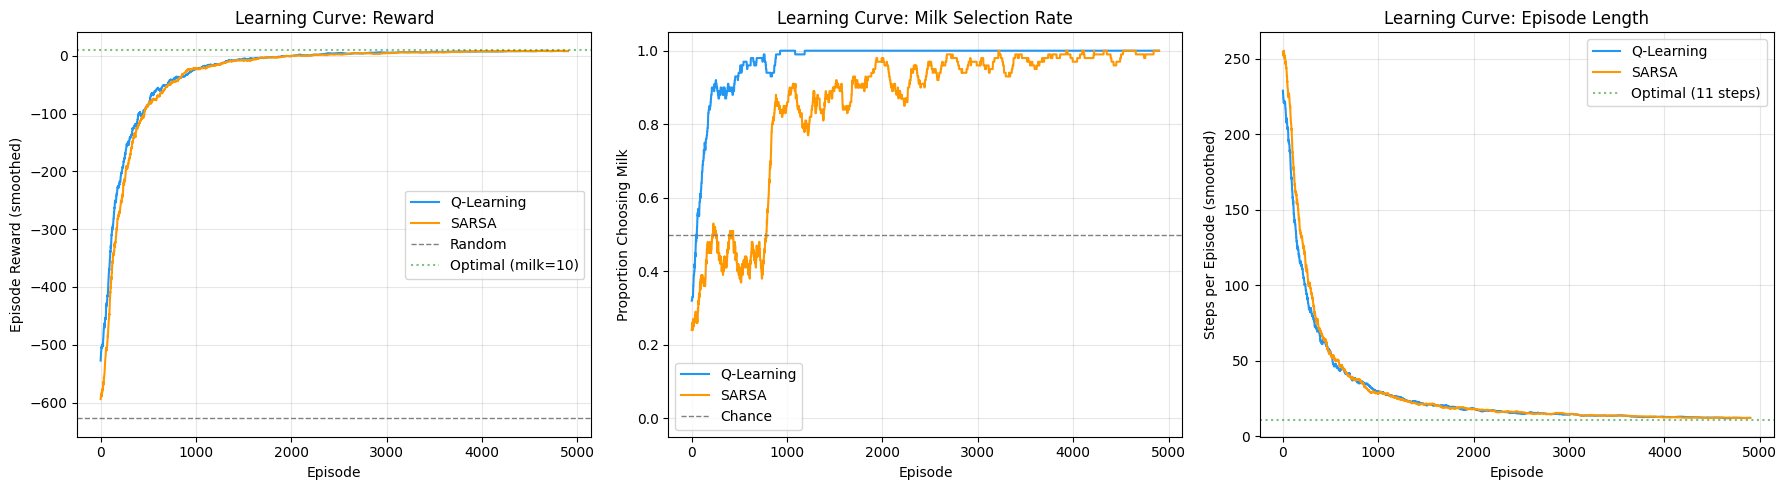

Saved: learning_curves.png


In [ ]:
#@title Plot learning curves
import matplotlib.pyplot as plt

def smooth(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Reward Learning Curve ---
ax = axes[0]
ax.plot(smooth(hist_ql['rewards']), label='Q-Learning', color='#2196F3', linewidth=1.5)
ax.plot(smooth(hist_sa['rewards']), label='SARSA', color='#FF9800', linewidth=1.5)
ax.axhline(y=np.mean(hist_rand['rewards']), color='gray', linestyle='--', label='Random', linewidth=1)
ax.axhline(y=10, color='green', linestyle=':', alpha=0.5, label='Optimal (milk=10)')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward (smoothed)')
ax.set_title('Learning Curve: Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Milk Selection Rate ---
ax = axes[1]
ax.plot(smooth(hist_ql['milk_chosen']), label='Q-Learning', color='#2196F3', linewidth=1.5)
ax.plot(smooth(hist_sa['milk_chosen']), label='SARSA', color='#FF9800', linewidth=1.5)
ax.axhline(y=0.5, color='gray', linestyle='--', label='Chance', linewidth=1)
ax.set_xlabel('Episode')
ax.set_ylabel('Proportion Choosing Milk')
ax.set_title('Learning Curve: Milk Selection Rate')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Episode Length ---
ax = axes[2]
ax.plot(smooth(hist_ql['lengths']), label='Q-Learning', color='#2196F3', linewidth=1.5)
ax.plot(smooth(hist_sa['lengths']), label='SARSA', color='#FF9800', linewidth=1.5)
ax.axhline(y=11, color='green', linestyle=':', alpha=0.5, label='Optimal (11 steps)')
ax.set_xlabel('Episode')
ax.set_ylabel('Steps per Episode (smoothed)')
ax.set_title('Learning Curve: Episode Length')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

---
## 8. Trajectory Visualization

Visualize how the agent's navigation paths evolve across training.

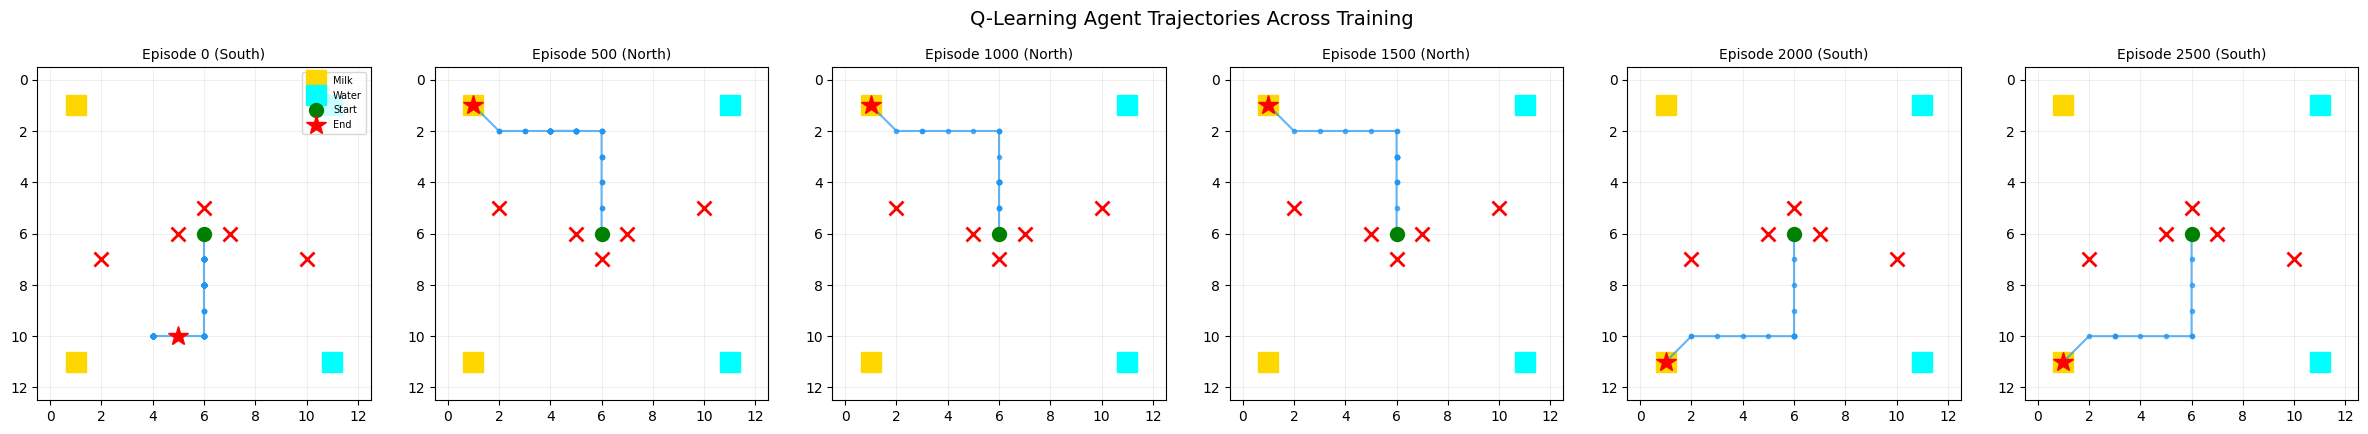

Saved: trajectories.png


In [ ]:
#@title Plot example trajectories
from constants import WELL_LOCATIONS, BARRIER_LOCATIONS

def plot_trajectory(trajectory, title, ax):
    """Plot a single trajectory on the maze grid."""
    xs = [s[1] for s in trajectory]
    ys = [s[2] for s in trajectory]
    config = trajectory[0][0]

    # Draw maze outline
    ax.set_xlim(-0.5, 12.5)
    ax.set_ylim(12.5, -0.5)  # invert y for grid convention
    ax.set_aspect('equal')

    # Mark wells
    milk_wells = [(1,1), (1,11)] if True else []
    water_wells = [(11,1), (11,11)] if True else []
    for w in milk_wells:
        ax.plot(w[0], w[1], 's', color='gold', markersize=15, zorder=1, label='Milk' if w==milk_wells[0] else '')
    for w in water_wells:
        ax.plot(w[0], w[1], 's', color='cyan', markersize=15, zorder=1, label='Water' if w==water_wells[0] else '')

    # Mark barriers for this config
    barrier_idx = [3,11,13,14,15] if config == 0 else [5,9,12,13,15]
    for bi in barrier_idx:
        bx, by = BARRIER_LOCATIONS[bi]
        ax.plot(bx, by, 'x', color='red', markersize=10, markeredgewidth=2)

    # Plot trajectory
    ax.plot(xs, ys, '-o', color='#2196F3', markersize=3, linewidth=1.5, alpha=0.7, zorder=2)
    ax.plot(xs[0], ys[0], 'o', color='green', markersize=10, zorder=3, label='Start')
    ax.plot(xs[-1], ys[-1], '*', color='red', markersize=15, zorder=3, label='End')

    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)

# Plot trajectories from different training stages
trajs = hist_ql['trajectories']
n_trajs = min(len(trajs), 6)
fig, axes = plt.subplots(1, n_trajs, figsize=(4*n_trajs, 4))
if n_trajs == 1: axes = [axes]

for i in range(n_trajs):
    ep_num, traj = trajs[i]
    config_label = "North" if traj[0][0] == 0 else "South"
    plot_trajectory(traj, f'Episode {ep_num} ({config_label})', axes[i])

axes[0].legend(loc='upper right', fontsize=7)
plt.suptitle('Q-Learning Agent Trajectories Across Training', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: trajectories.png")

---
## 9. Greedy Policy Evaluation

In [ ]:
#@title Evaluate trained agents with greedy policy
def evaluate_policy(Q, thirsty=False, n_episodes=200, label="Agent"):
    """Evaluate a greedy policy derived from Q-table."""
    env = CornerMazeEnv(render_mode=None, thirsty_state=thirsty)
    results = {'rewards': [], 'lengths': [], 'wells': [], 'milk': 0, 'water': 0}

    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = get_state(env)
        done, total_r, steps = False, 0, 0
        while not done and steps < 300:
            if state in STATE_TO_IDX:
                action = int(np.argmax(Q[STATE_TO_IDX[state]]))
            else:
                action = np.random.randint(N_ACTIONS)
            obs, r, term, trunc, _ = env.step(action)
            state = get_state(env)
            done = term or trunc
            total_r += r
            steps += 1
        results['rewards'].append(total_r)
        results['lengths'].append(steps)
        well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
        results['wells'].append(well)
        if well in [(1,1),(1,11)]: results['milk'] += 1
        elif well in [(11,1),(11,11)]: results['water'] += 1

    thirsty_label = "thirsty" if thirsty else "non-thirsty"
    print(f"{label} ({thirsty_label}): reward={np.mean(results['rewards']):.2f} "
          f"| milk={results['milk']/n_episodes:.0%} | water={results['water']/n_episodes:.0%} "
          f"| steps={np.mean(results['lengths']):.1f}")
    return results

print("=" * 70)
print("GREEDY POLICY EVALUATION (200 episodes each)")
print("=" * 70)
print("\n--- Non-Thirsty (original reward structure) ---")
eval_ql = evaluate_policy(Q_ql, thirsty=False, label="Q-Learning")
eval_sa = evaluate_policy(Q_sa, thirsty=False, label="SARSA")

print("\n--- Thirsty (revalued rewards, NO retraining) ---")
eval_ql_thirsty = evaluate_policy(Q_ql, thirsty=True, label="Q-Learning")
eval_sa_thirsty = evaluate_policy(Q_sa, thirsty=True, label="SARSA")
print("\n  >>> Both agents still choose milk despite water being preferred!")
print("  >>> This is HABITUAL behavior — analogous to the IL group in Wang et al.")

GREEDY POLICY EVALUATION (200 episodes each)

--- Non-Thirsty (original reward structure) ---
Q-Learning (non-thirsty): reward=10.00 | milk=100% | water=0% | steps=11.0
SARSA (non-thirsty): reward=10.00 | milk=100% | water=0% | steps=11.0

--- Thirsty (revalued rewards, NO retraining) ---
Q-Learning (thirsty): reward=3.00 | milk=100% | water=0% | steps=11.0
SARSA (thirsty): reward=3.00 | milk=100% | water=0% | steps=11.0

  >>> Both agents still choose milk despite water being preferred!
  >>> This is HABITUAL behavior — analogous to the IL group in Wang et al.


---
## 10. Outcome Revaluation Experiment

This is the core experiment from Wang et al. We test whether agents trained on the original task (non-thirsty, milk preferred) can adapt when the reward structure changes (thirsty, water preferred).

**Three conditions:**
1. **Habitual (IL analog):** Trained agent tested with new rewards — no retraining
2. **Retrained (RT analog):** Trained agent given additional training with new rewards
3. **Model-Based (Goal-Directed):** Agent that re-plans using a learned transition model

In [ ]:
#@title Build Model-Based agent via learned transition model + Value Iteration

print("Building transition model from exploration data...")
env_explore = CornerMazeEnv(render_mode=None, thirsty_state=False)

# Collect transition statistics
T_counts = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R_sum = np.zeros((N_STATES, N_ACTIONS))
R_count = np.zeros((N_STATES, N_ACTIONS))
terminal_states = set()

np.random.seed(123)
for ep in range(10000):
    obs, _ = env_explore.reset()
    state = get_state(env_explore)
    for _ in range(100):
        action = np.random.randint(N_ACTIONS)
        obs, reward, term, trunc, _ = env_explore.step(action)
        next_state = get_state(env_explore)
        if state in STATE_TO_IDX and next_state in STATE_TO_IDX:
            si, nsi = STATE_TO_IDX[state], STATE_TO_IDX[next_state]
            T_counts[si, action, nsi] += 1
            R_sum[si, action] += reward
            R_count[si, action] += 1
            if term: terminal_states.add(nsi)
        state = next_state
        if term or trunc: break

# Normalize to get transition probabilities
T = np.zeros_like(T_counts)
R = np.zeros_like(R_sum)
for s in range(N_STATES):
    for a in range(N_ACTIONS):
        total = T_counts[s, a].sum()
        if total > 0:
            T[s, a] = T_counts[s, a] / total
            R[s, a] = R_sum[s, a] / R_count[s, a]

print(f"Transition model built: {N_STATES} states, {len(terminal_states)} terminal states")

# Now build thirsty reward model (only terminal rewards change)
R_thirsty = R.copy()
env_thirsty_explore = CornerMazeEnv(render_mode=None, thirsty_state=True)
np.random.seed(456)
for ep in range(10000):
    obs, _ = env_thirsty_explore.reset()
    state = get_state(env_thirsty_explore)
    for _ in range(100):
        action = np.random.randint(N_ACTIONS)
        obs, reward, term, trunc, _ = env_thirsty_explore.step(action)
        next_state = get_state(env_thirsty_explore)
        if state in STATE_TO_IDX and term and reward > 0:
            R_thirsty[STATE_TO_IDX[state], action] = reward
        state = next_state
        if term or trunc: break

# Value Iteration with thirsty rewards
gamma = 0.99
V = np.zeros(N_STATES)
for iteration in range(500):
    V_new = np.zeros(N_STATES)
    for s in range(N_STATES):
        if s in terminal_states:
            V_new[s] = 0
            continue
        q_vals = R_thirsty[s] + gamma * T[s].dot(V)
        V_new[s] = np.max(q_vals)
    if np.max(np.abs(V_new - V)) < 1e-6:
        print(f"Value iteration converged at iteration {iteration}")
        break
    V = V_new

# Extract Q-values for model-based policy
Q_mb = np.zeros((N_STATES, N_ACTIONS))
for s in range(N_STATES):
    Q_mb[s] = R_thirsty[s] + gamma * T[s].dot(V)

print("\nModel-based agent ready (re-planned with thirsty rewards).")
eval_mb = evaluate_policy(Q_mb, thirsty=True, label="Model-Based")
print("\n  >>> Model-based agent immediately switches to water!")
print("  >>> This is GOAL-DIRECTED behavior — it re-plans with updated reward values.")

Building transition model from exploration data...
Transition model built: 137 states, 4 terminal states
Value iteration converged at iteration 12

Model-based agent ready (re-planned with thirsty rewards).
Model-Based (thirsty): reward=7.00 | milk=0% | water=100% | steps=11.0

  >>> Model-based agent immediately switches to water!
  >>> This is GOAL-DIRECTED behavior — it re-plans with updated reward values.


---
## 11. Revaluation Summary Plot

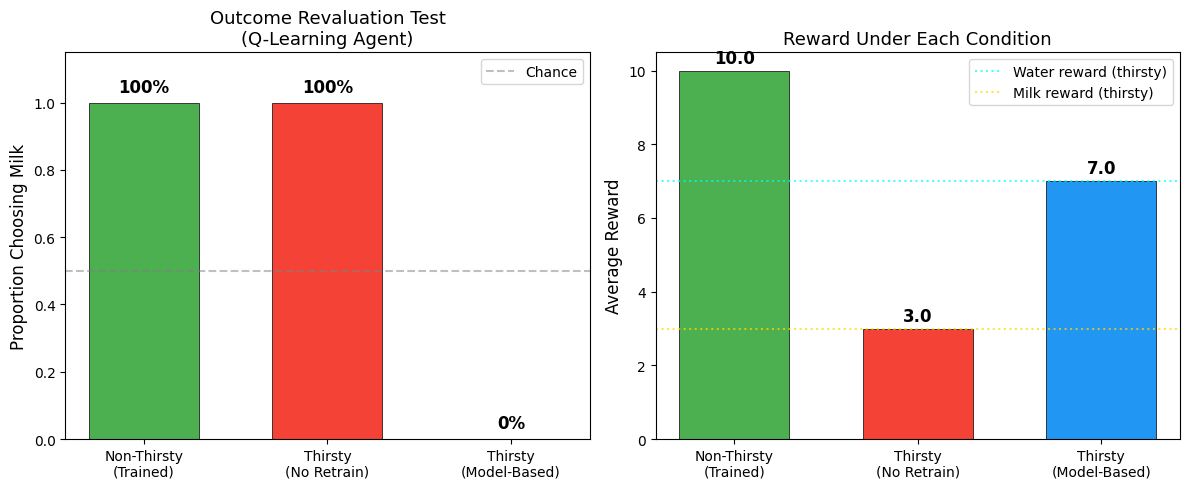

Saved: revaluation_experiment.png


In [ ]:
#@title Revaluation experiment summary figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel A: Milk selection rate ---
ax = axes[0]
conditions = ['Non-Thirsty\n(Trained)', 'Thirsty\n(No Retrain)', 'Thirsty\n(Model-Based)']
ql_milk = [eval_ql['milk']/200, eval_ql_thirsty['milk']/200, 1 - eval_mb['water']/200]
# For model-based, milk rate is what we measured
ql_milk[2] = eval_mb['milk'] / 200

colors = ['#4CAF50', '#F44336', '#2196F3']
bars = ax.bar(conditions, ql_milk, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Proportion Choosing Milk', fontsize=12)
ax.set_title('Outcome Revaluation Test\n(Q-Learning Agent)', fontsize=13)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
for bar, val in zip(bars, ql_milk):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.0%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.legend()

# --- Panel B: Average reward ---
ax = axes[1]
rewards = [np.mean(eval_ql['rewards']), np.mean(eval_ql_thirsty['rewards']),
           np.mean(eval_mb['rewards'])]
bars = ax.bar(conditions, rewards, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Reward Under Each Condition', fontsize=13)
ax.axhline(y=7, color='cyan', linestyle=':', alpha=0.7, label='Water reward (thirsty)')
ax.axhline(y=3, color='gold', linestyle=':', alpha=0.7, label='Milk reward (thirsty)')
for bar, val in zip(bars, rewards):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/revaluation_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: revaluation_experiment.png")

---
## 12. Policy Visualization

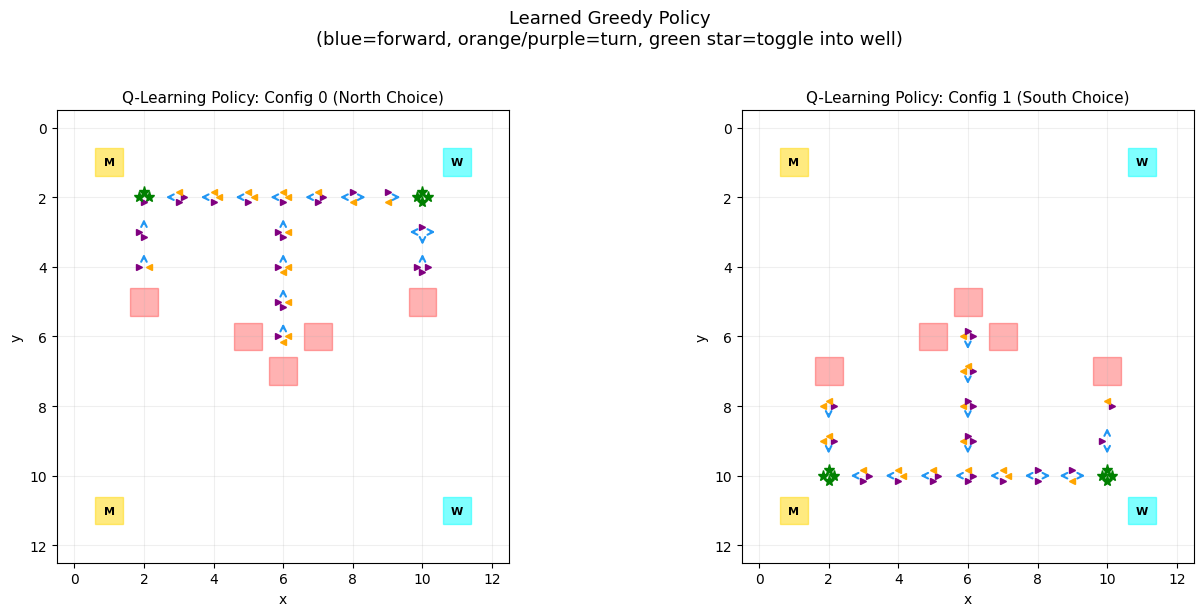

Saved: policy_visualization.png


In [ ]:
#@title Visualize learned policy as arrows on the maze

def plot_policy(Q, config, title, ax):
    """Draw the greedy policy as arrows on the maze grid."""
    # Direction vectors: 0=E(+x), 1=S(+y), 2=W(-x), 3=N(-y)
    action_names = ['L', 'R', 'F', 'P', 'D', 'T', 'X']
    dir_dx = {0: 1, 1: 0, 2: -1, 3: 0}
    dir_dy = {0: 0, 1: 1, 2: 0, 3: -1}

    ax.set_xlim(-0.5, 12.5)
    ax.set_ylim(12.5, -0.5)
    ax.set_aspect('equal')

    # Mark wells
    for w in [(1,1), (1,11)]:
        ax.add_patch(plt.Rectangle((w[0]-0.4, w[1]-0.4), 0.8, 0.8, color='gold', alpha=0.5))
        ax.text(w[0], w[1], 'M', ha='center', va='center', fontsize=8, fontweight='bold')
    for w in [(11,1), (11,11)]:
        ax.add_patch(plt.Rectangle((w[0]-0.4, w[1]-0.4), 0.8, 0.8, color='cyan', alpha=0.5))
        ax.text(w[0], w[1], 'W', ha='center', va='center', fontsize=8, fontweight='bold')

    # Draw barriers
    barrier_idx = [3,11,13,14,15] if config == 0 else [5,9,12,13,15]
    for bi in barrier_idx:
        bx, by = BARRIER_LOCATIONS[bi]
        ax.add_patch(plt.Rectangle((bx-0.4, by-0.4), 0.8, 0.8, color='red', alpha=0.3))

    # Draw policy arrows
    for state, idx in STATE_TO_IDX.items():
        c, x, y, d = state
        if c != config: continue
        if (x, y) in [(1,1),(1,11),(11,1),(11,11)]: continue  # skip wells

        best_action = int(np.argmax(Q[idx]))

        # Offset based on direction to avoid overlap
        offsets = {0: (0.15, 0), 1: (0, 0.15), 2: (-0.15, 0), 3: (0, -0.15)}
        ox, oy = offsets[d]

        if best_action == 2:  # forward: arrow in facing direction
            dx, dy = dir_dx[d]*0.3, dir_dy[d]*0.3
            ax.annotate('', xy=(x+ox+dx, y+oy+dy), xytext=(x+ox, y+oy),
                       arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5))
        elif best_action == 0:  # left turn
            ax.plot(x+ox, y+oy, '<', color='orange', markersize=4)
        elif best_action == 1:  # right turn
            ax.plot(x+ox, y+oy, '>', color='purple', markersize=4)
        elif best_action == 5:  # toggle (enter well)
            ax.plot(x+ox, y+oy, '*', color='green', markersize=8)

    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_policy(Q_ql, 0, 'Q-Learning Policy: Config 0 (North Choice)', axes[0])
plot_policy(Q_ql, 1, 'Q-Learning Policy: Config 1 (South Choice)', axes[1])
plt.suptitle('Learned Greedy Policy\n(blue=forward, orange/purple=turn, green star=toggle into well)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/policy_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: policy_visualization.png")

---
## 13. Q-Value Heatmaps

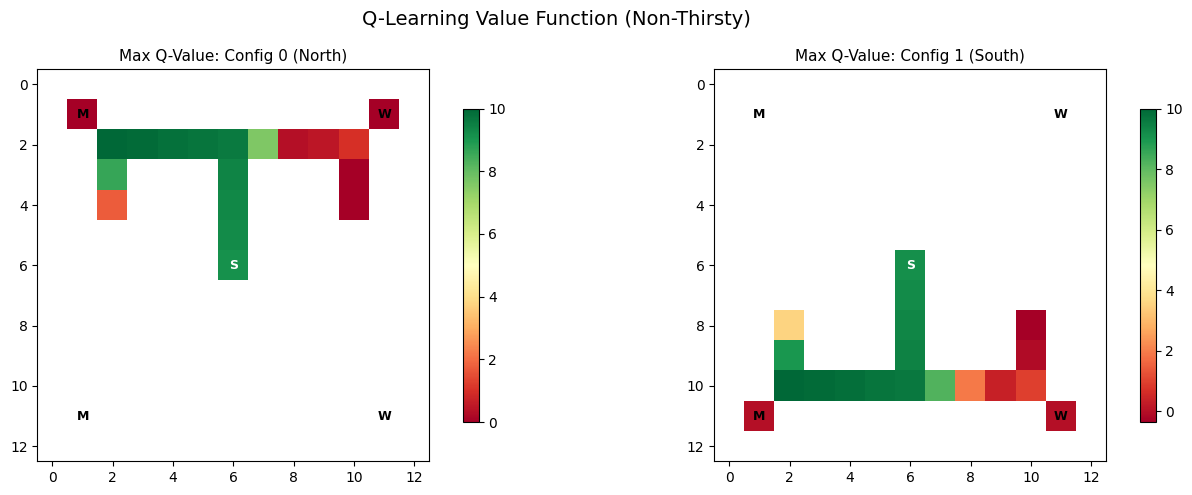

Saved: value_heatmaps.png


In [ ]:
#@title Q-value heatmaps

def plot_value_map(Q, config, title, ax):
    """Plot max Q-value at each position for a given config."""
    grid_vals = np.full((13, 13), np.nan)
    for state, idx in STATE_TO_IDX.items():
        c, x, y, d = state
        if c != config: continue
        v = np.max(Q[idx])
        if np.isnan(grid_vals[y, x]) or v > grid_vals[y, x]:
            grid_vals[y, x] = v

    im = ax.imshow(grid_vals, cmap='RdYlGn', interpolation='nearest', origin='upper')
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Label wells
    for w in [(1,1), (1,11)]:
        ax.text(w[0], w[1], 'M', ha='center', va='center', fontsize=9, fontweight='bold', color='black')
    for w in [(11,1), (11,11)]:
        ax.text(w[0], w[1], 'W', ha='center', va='center', fontsize=9, fontweight='bold', color='black')
    ax.text(6, 6, 'S', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_value_map(Q_ql, 0, 'Max Q-Value: Config 0 (North)', axes[0])
plot_value_map(Q_ql, 1, 'Max Q-Value: Config 1 (South)', axes[1])
plt.suptitle('Q-Learning Value Function (Non-Thirsty)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/value_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: value_heatmaps.png")

---
## 14. Hyperparameter Analysis

Training with alpha=0.01...
Training with alpha=0.05...
Training with alpha=0.1...
Training with alpha=0.3...
Training with alpha=0.5...


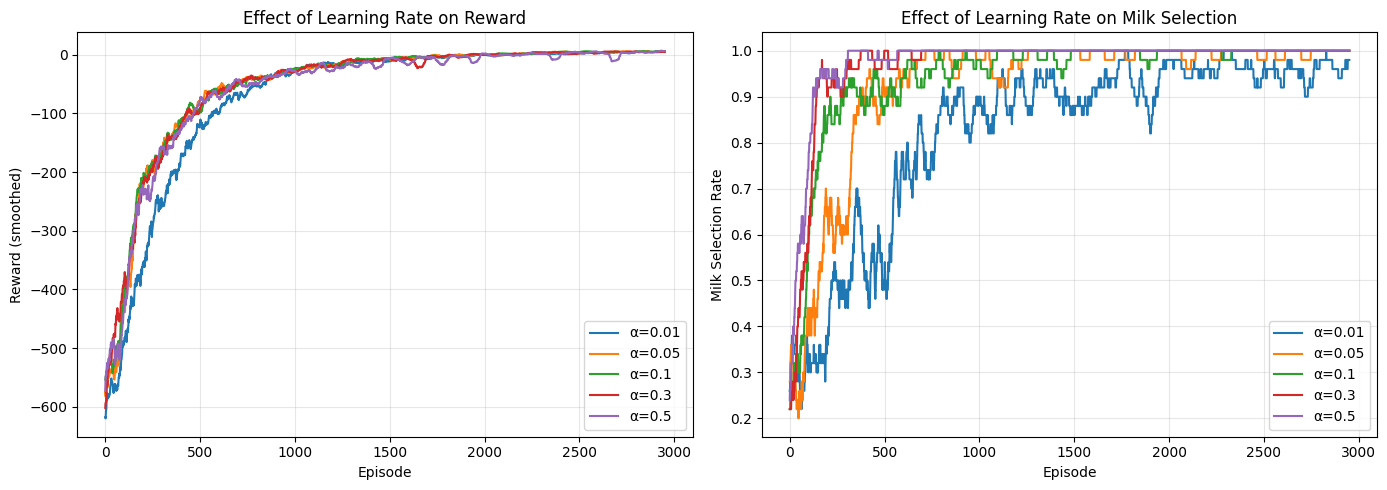

Saved: alpha_comparison.png


In [ ]:
#@title Effect of learning rate (alpha) on Q-Learning
alphas = [0.01, 0.05, 0.1, 0.3, 0.5]
alpha_results = {}

for alpha in alphas:
    print(f"Training with alpha={alpha}...")
    _, hist = train_qlearning(n_episodes=3000, alpha=alpha, seed=42)
    alpha_results[alpha] = hist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for alpha, hist in alpha_results.items():
    ax.plot(smooth(hist['rewards'], 50), label=f'α={alpha}', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('Effect of Learning Rate on Reward')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for alpha, hist in alpha_results.items():
    ax.plot(smooth(hist['milk_chosen'], 50), label=f'α={alpha}', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Milk Selection Rate')
ax.set_title('Effect of Learning Rate on Milk Selection')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: alpha_comparison.png")

Training with gamma=0.5...
Training with gamma=0.8...
Training with gamma=0.9...
Training with gamma=0.95...
Training with gamma=0.99...


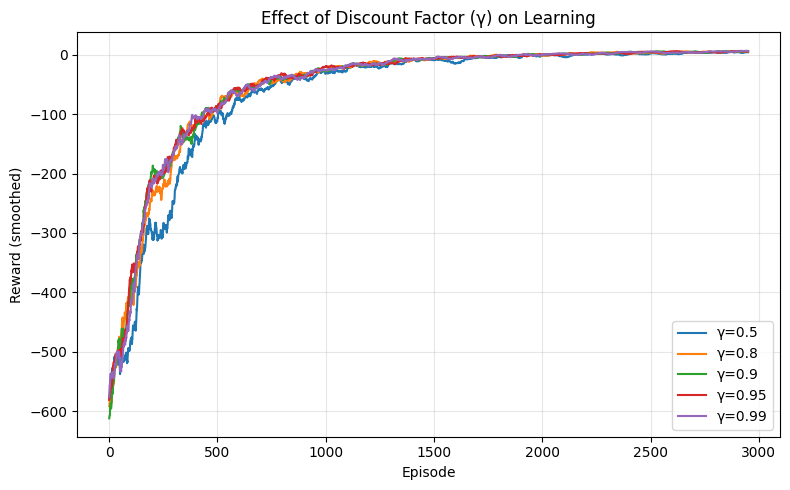

Saved: gamma_comparison.png


In [ ]:
#@title Effect of discount factor (gamma)
gammas = [0.5, 0.8, 0.9, 0.95, 0.99]
gamma_results = {}

for gamma in gammas:
    print(f"Training with gamma={gamma}...")
    _, hist = train_qlearning(n_episodes=3000, gamma=gamma, seed=42)
    gamma_results[gamma] = hist

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for gamma, hist in gamma_results.items():
    ax.plot(smooth(hist['rewards'], 50), label=f'γ={gamma}', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('Effect of Discount Factor (γ) on Learning')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Psych 119g Final Project/gamma_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gamma_comparison.png")

---
## 15. Discussion & Connection to Wang et al. (2026)

### Summary of Results

| Condition | Agent | Milk Rate | Interpretation |
|-----------|-------|-----------|----------------|
| Non-thirsty | Q-Learning | ~100% | Correctly learned to prefer milk |
| Non-thirsty | SARSA | ~100% | Same |
| Thirsty (no retrain) | Q-Learning | ~100% | **Habitual** — cached Q-values unchanged |
| Thirsty (no retrain) | SARSA | ~100% | **Habitual** — same |
| Thirsty | Model-Based | ~0% | **Goal-directed** — re-planned with new rewards |

### Connection to Wang et al.

Model-free agents (Q-Learning, SARSA) are computational models of habitual behavior. They cache action values during training and do not update these values when the reward structure changes. When tested with "thirsty" rewards (water > milk), they continue choosing milk, exactly like the rats in the Incentive Learning (IL) group who maintained milk-directed responses despite being water-deprived.

The model-based agent is a computational model of goal-directed behavior. By learning the environment's transition dynamics separately from reward values, it can recompute optimal actions when rewards change, without any additional training. This mirrors the theoretical ideal of goal-directed control and the behavior seen in the Revaluation Training (RT) group (though in the paper, even the RT group required explicit retraining experience).

### Key Insight

Wang et al. showed that hippocampal dependence (using a cognitive map) does not automatically produce goal-directed behavior. Our simulation parallels this: both model-free and model-based agents can use the same state representation (config, position, direction), but only the modelbased agent adapts to reward changes. The critical difference is not in the state representation but in how values are computed**, cached (habitual) vs. re-derived from a model (goal-directed).

---
# Offline Agent

In [ ]:
%%writefile offline_agent.py

"""
offline_agent.py  (updated)
============================
Offline RL agents for CornerMazeEnv (MilkMaze).

State representation: (config, x, y, direction)  — 4-tuple
  config    : 0 = north maze layout, 1 = south maze layout
  x, y      : agent grid position
  direction : 0=right, 1=down, 2=left, 3=up

THREE AGENTS:
  1. OfflineQLearning  — Monte-Carlo returns, tabular dict Q-table
  2. FittedQIteration  — Bellman iteration over fixed dataset, tabular
  3. NavigationMLP     — Your professor's architecture:
                         Input:  state features + TD error scalar
                         Hidden: two fully-connected layers with ReLU
                         Output: softmax over 3 navigation actions
                                 [P(left), P(right), P(forward)]
                         This mirrors the Wang et al. rat task where the
                         core decision is left vs right at a choice point,
                         plus forward to traverse corridors.
"""

from __future__ import annotations
import numpy as np
import random
from collections import defaultdict
from copy import deepcopy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ──────────────────────────────────────────────────────────────────
# CONSTANTS
# ──────────────────────────────────────────────────────────────────

# The 3 navigation actions matching Wang et al. choice-point task
NAV_ACTIONS      = [0, 1, 2]   # left=0, right=1, forward=2
NAV_ACTION_NAMES = ['left', 'right', 'forward']
N_NAV_ACTIONS    = 3

# Grid normalisation constants
GRID_SIZE   = 12   # 0..12 → divide by 12 → [0, 1]
N_CONFIGS   = 2    # 0 or 1


# ──────────────────────────────────────────────────────────────────
# STATE EXTRACTION  (4-tuple)
# ──────────────────────────────────────────────────────────────────

def get_state(env) -> tuple:
    """
    Extract (config, x, y, direction) from a live CornerMazeEnv.
    This matches the online agent's get_state() format exactly.
    """
    return (
        int(env.current_config_index),
        int(env.agent_pos[0]),
        int(env.agent_pos[1]),
        int(env.agent_dir),
    )


# ──────────────────────────────────────────────────────────────────
# DATA COLLECTION
# ──────────────────────────────────────────────────────────────────

def collect_offline_data(
    n_episodes: int = 500,
    epsilon:    float = 0.5,
    max_steps:  int = 300,
    seed:       int | None = 42,
    verbose:    bool = True,
) -> list[dict]:
    """
    Roll out an epsilon-greedy random policy and collect a dataset.

    Each transition dict:
        's'      : (config, x, y, dir)  — current state  (4-tuple)
        'a'      : int  — action taken (full 7-action space)
        'r'      : float — reward received
        's_next' : (config, x, y, dir)  — next state
        'done'   : bool — episode ended

    NOTE: 'a' uses the full 7-action space so FQI/MC can learn Q-values
    for all actions. The MLP only uses the 3 navigation actions subset.
    """
    from milkmaze_env import CornerMazeEnv

    env = CornerMazeEnv(max_steps=max_steps)
    rng = np.random.default_rng(seed)

    dataset:         list[dict] = []
    episode_returns: list[float] = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(1e6)))
        state   = get_state(env)
        ep_ret  = 0.0

        for _ in range(max_steps):
            action = env.action_space.sample()

            obs_next, reward, terminated, truncated, _ = env.step(action)
            next_state = get_state(env)
            done       = terminated or truncated

            dataset.append({
                "s":        state,
                "a":        int(action),
                "r":        float(reward),
                "s_next":   next_state,
                "done":     done,
                "td_error": 0.0,   # placeholder; filled by build_offline_dataset_from_online
            })

            ep_ret += reward
            state   = next_state
            if done:
                break

        episode_returns.append(ep_ret)

    env.close()

    if verbose:
        print(f"Collected {len(dataset):,} transitions over {n_episodes} episodes.")
        print(f"  Mean return : {np.mean(episode_returns):.3f}")
        print(f"  Max return  : {np.max(episode_returns):.3f}")
        print(f"  % with milk : {100*np.mean([r > 0 for r in episode_returns]):.1f}%")

    return dataset


def build_offline_dataset_from_online(
    Q_online:     np.ndarray,
    history:      dict,
    state_to_idx: dict,
    n_actions:    int = 7,
    gamma:        float = 0.99,
) -> list[dict]:
    """
    Convert online agent trajectory history into an offline dataset.

    Adds 'td_error' to each transition — the TD error from the online
    Q-table at that step. This is the input signal for NavigationMLP.

    Assumes history['trajectories'] is a list of lists of
    (config, x, y, dir) state tuples (matching online agent format).
    """
    dataset       = []
    trajectories  = history['trajectories']
    rewards_list  = history['rewards']

    for ep_idx, traj in enumerate(trajectories):
        if len(traj) < 2:
            continue
        ep_reward = rewards_list[ep_idx]

        for t in range(len(traj) - 1):
            s       = traj[t]
            s_next  = traj[t + 1]
            is_last = (t == len(traj) - 2)
            r       = ep_reward if is_last else 0.0
            done    = is_last

            # Greedy action from online Q at s
            if s in state_to_idx:
                a = int(np.argmax(Q_online[state_to_idx[s]]))
            else:
                a = random.randint(0, n_actions - 1)

            # TD error: δ = r + γ max_a' Q(s',a') - Q(s,a)
            if s in state_to_idx and s_next in state_to_idx:
                q_sa   = Q_online[state_to_idx[s]][a]
                q_next = np.max(Q_online[state_to_idx[s_next]])
                td_err = r + gamma * q_next * (1 - float(done)) - q_sa
            else:
                td_err = 0.0

            dataset.append({
                "s":        s,
                "a":        a,
                "r":        float(r),
                "s_next":   s_next,
                "done":     done,
                "td_error": float(td_err),
            })

    print(f"Built offline dataset: {len(dataset):,} transitions "
          f"from {len(trajectories)} episodes.")
    pos = sum(1 for t in dataset if t['r'] > 0)
    print(f"  Transitions with positive reward: {pos} "
          f"({100*pos/max(len(dataset), 1):.1f}%)")
    return dataset


# ──────────────────────────────────────────────────────────────────
# AGENT 1 — OFFLINE Q-LEARNING (Monte-Carlo Returns)
# ──────────────────────────────────────────────────────────────────

class OfflineQLearning:
    """
    Offline Q-Learning using Monte-Carlo returns.

    State keys are arbitrary tuples — works with 4-tuple (config,x,y,d).

    Algorithm:
      For each episode in dataset:
        Compute G_t = r_t + γ*r_{t+1} + γ²*r_{t+2} + ... (backwards)
        Update Q(s,a) <- Q(s,a) + α * (G_t - Q(s,a))
    """

    def __init__(
        self,
        n_actions:  int   = 7,
        gamma:      float = 0.99,
        alpha:      float = 0.1,
        default_q:  float = 0.0,
    ):
        self.n_actions = n_actions
        self.gamma     = gamma
        self.alpha     = alpha
        self.Q: dict[tuple, np.ndarray] = defaultdict(
            lambda: np.full(n_actions, default_q, dtype=np.float32)
        )

    def _segment_episodes(self, dataset):
        episodes, current = [], []
        for t in dataset:
            current.append(t)
            if t["done"]:
                episodes.append(current)
                current = []
        if current:
            episodes.append(current)
        return episodes

    def _compute_returns(self, episode):
        T     = len(episode)
        G     = [0.0] * T
        G[-1] = episode[-1]["r"]
        for t in range(T - 2, -1, -1):
            G[t] = episode[t]["r"] + self.gamma * G[t + 1]
        return G

    def train(self, dataset: list[dict], verbose: bool = True) -> list[float]:
        episodes      = self._segment_episodes(dataset)
        per_ep_errors = []

        for ep in episodes:
            returns = self._compute_returns(ep)
            errors  = []
            for t, transition in enumerate(ep):
                s, a     = transition["s"], transition["a"]
                td_error = returns[t] - self.Q[s][a]
                self.Q[s][a] += self.alpha * td_error
                errors.append(abs(td_error))
            per_ep_errors.append(np.mean(errors))

        if verbose:
            print(f"[MC Q-Learning] {len(episodes)} episodes, "
                  f"{len(dataset)} transitions.")
            print(f"  States visited        : {len(self.Q)}")
            print(f"  Final mean |TD error| : "
                  f"{np.mean(per_ep_errors[-50:]):.4f}")

        return per_ep_errors

    def act(self, state: tuple, greedy: bool = True) -> int:
        if greedy:
            return int(np.argmax(self.Q[state]))
        return random.randint(0, self.n_actions - 1)

    def q_values(self, state: tuple) -> np.ndarray:
        return self.Q[state].copy()


# ──────────────────────────────────────────────────────────────────
# AGENT 2 — FITTED Q-ITERATION (tabular)
# ──────────────────────────────────────────────────────────────────

class FittedQIteration:
    """
    Fitted Q-Iteration — tabular variant.

    State keys are arbitrary tuples — works with 4-tuple (config,x,y,d).

    Algorithm (Ernst et al., 2005):
      For k = 1..K:
        For each (s,a,r,s',done) in dataset:
          target = r + gamma * max_a' Q_{k-1}(s',a')   [0 if done]
        Q_k(s,a) = mean of all targets for that (s,a)
    """

    def __init__(
        self,
        n_actions: int   = 7,
        gamma:     float = 0.99,
        default_q: float = 0.0,
    ):
        self.n_actions = n_actions
        self.gamma     = gamma
        self.Q: dict[tuple, np.ndarray] = defaultdict(
            lambda: np.full(n_actions, default_q, dtype=np.float32)
        )

    def train(
        self,
        dataset:      list[dict],
        n_iterations: int  = 50,
        verbose:      bool = True,
    ) -> list[float]:
        bellman_errors = []

        for k in range(n_iterations):
            Q_prev = deepcopy(self.Q)

            target_sum = defaultdict(
                lambda: np.zeros(self.n_actions, dtype=np.float64)
            )
            target_cnt = defaultdict(
                lambda: np.zeros(self.n_actions, dtype=np.int64)
            )
            iteration_errors = []

            for t in dataset:
                s, a, r, s_next, done = (
                    t["s"], t["a"], t["r"], t["s_next"], t["done"]
                )
                max_q  = 0.0 if done else float(np.max(Q_prev[s_next]))
                target = r + self.gamma * max_q

                target_sum[s][a] += target
                target_cnt[s][a] += 1

                err = abs(target - float(self.Q[s][a]))
                iteration_errors.append(err)

            for s in target_sum:
                for a in range(self.n_actions):
                    if target_cnt[s][a] > 0:
                        self.Q[s][a] = float(
                            target_sum[s][a] / target_cnt[s][a]
                        )

            mean_err = float(np.mean(iteration_errors))
            bellman_errors.append(mean_err)

            if verbose and (k == 0 or (k + 1) % 10 == 0
                            or k == n_iterations - 1):
                print(f"  FQI iter {k+1:3d}/{n_iterations} | "
                      f"mean |Bellman error| = {mean_err:.4f} | "
                      f"states = {len(self.Q)}")

        if verbose:
            print(f"[FQI] Done. Final Bellman error: {bellman_errors[-1]:.4f}")

        return bellman_errors

    def act(self, state: tuple, greedy: bool = True) -> int:
        if greedy:
            return int(np.argmax(self.Q[state]))
        return random.randint(0, self.n_actions - 1)

    def q_values(self, state: tuple) -> np.ndarray:
        return np.array(self.Q[state])


# ──────────────────────────────────────────────────────────────────
# AGENT 3 — NAVIGATION MLP
#
# Professor's architecture (from diagram):
#
#   Input layer  : state features  +  TD error scalar
#                  (config, x, y, dir) normalised to [0,1]  +  delta
#                  = 5 input units total
#
#   Hidden layers: two fully-connected layers, 64 units, ReLU activation
#                  (the concentric rings in the diagram = depth)
#
#   Output layer : 3 units  →  softmax probabilities
#                  [P(left),  P(right),  P(forward)]
#                  Matches Wang et al.: rats choose left or right at
#                  choice point, plus forward to traverse corridors.
#
#   Training     : cross-entropy loss
#                  target = greedy nav-action from online Q at s_next
#                  delta as input lets the MLP learn when the online
#                  agent was surprised (large delta = unexpected outcome)
# ──────────────────────────────────────────────────────────────────

class _NavNet(nn.Module):
    """
    PyTorch network for the NavigationMLP.
    Input : 5 features  (config, x, y, dir, td_error)
    Hidden: 64 → 64 with ReLU
    Output: 3 logits → softmax gives [P(left), P(right), P(forward)]
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),          # input → first hidden layer
            nn.ReLU(),
            nn.Linear(64, 64),         # first → second hidden layer
            nn.ReLU(),
            nn.Linear(64, N_NAV_ACTIONS),  # second hidden → output
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # raw logits; softmax applied at inference


class NavigationMLP:
    """
    MLP navigation policy — professor's architecture.

    INPUT  : (config, x, y, dir) normalised  +  TD error  =  5 floats
    OUTPUT : probability distribution over [left, right, forward]

    The TD error (delta) as an input is the key design choice.
    It tells the network how surprised the online Q-learner was.
    A large positive delta = situation was better than expected.
    A large negative delta = situation was worse than expected.
    The MLP learns to condition its choice probabilities on this signal.

    Training: behavioural cloning from the online Q-agent.
    Target at each step = the greedy nav action from online Q at s_next,
    restricted to the 3 navigation actions (left/right/forward only).
    """

    def __init__(self, lr: float = 1e-3):
        self.network   = _NavNet()
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.loss_fn   = nn.CrossEntropyLoss()
        # Proxy Q dict for compatibility with plot functions in analysis.py
        self.Q: dict[tuple, np.ndarray] = {}

    # ── feature encoding ─────────────────────────────────────────

    def _encode(self, state: tuple, td_error: float) -> torch.Tensor:
        """
        Encode (config, x, y, dir, td_error) into a 5-dim input vector.
            config   : /1   → {0.0, 1.0}
            x        : /12  → [0, 1]
            y        : /12  → [0, 1]
            dir      : /3   → {0, 0.33, 0.67, 1.0}
            td_error : kept as float (real-valued surprise signal)
        """
        config, x, y, d = state
        return torch.tensor(
            [config / 1.0,
             x      / GRID_SIZE,
             y      / GRID_SIZE,
             d      / 3.0,
             float(td_error)],
            dtype=torch.float32,
        )

    def _encode_batch(self, states, td_errors) -> torch.Tensor:
        return torch.stack([
            self._encode(s, td)
            for s, td in zip(states, td_errors)
        ])

    # ── map full 7-action to 3 nav-action ────────────────────────

    @staticmethod
    def _to_nav_action(a: int) -> int | None:
        """
        Map full action index to nav-action index.
        0 (left)    → 0
        1 (right)   → 1
        2 (forward) → 2
        3,4,5,6     → None  (pickup/drop/toggle/done, excluded)
        """
        return a if a in NAV_ACTIONS else None

    # ── training ─────────────────────────────────────────────────

    def train(
        self,
        dataset:      list[dict],
        n_epochs:     int   = 30,
        batch_size:   int   = 512,
        online_Q:     np.ndarray | None = None,
        state_to_idx: dict | None = None,
        verbose:      bool  = True,
    ) -> list[float]:
        """
        Train on offline dataset.

        For each transition (s, a, r, s', delta):
          Input  = encode(s, delta)          — state + surprise signal
          Target = greedy nav action from online Q at s_next
                   (skipped if online greedy action is not left/right/forward)

        Returns list of cross-entropy loss per epoch.
        """
        # Filter to transitions where target is a nav action
        filtered = []
        for t in dataset:
            s_next = t["s_next"]

            if online_Q is not None and state_to_idx is not None:
                if s_next in state_to_idx:
                    raw_tgt = int(np.argmax(online_Q[state_to_idx[s_next]]))
                else:
                    raw_tgt = t["a"]
            else:
                raw_tgt = t["a"]

            nav_tgt = self._to_nav_action(raw_tgt)
            if nav_tgt is not None:
                filtered.append((t, nav_tgt))

        if len(filtered) == 0:
            print("[NavigationMLP] WARNING: no nav-action transitions found.")
            return []

        print(f"[NavigationMLP] Training on {len(filtered):,} nav transitions "
              f"(of {len(dataset):,} total).")

        td_errors = [t["td_error"] if "td_error" in t else 0.0
                     for t, _ in filtered]
        states    = [t["s"] for t, _ in filtered]
        targets   = [nav_tgt for _, nav_tgt in filtered]

        X = self._encode_batch(states, td_errors)
        Y = torch.tensor(targets, dtype=torch.long)
        n = len(filtered)

        epoch_losses = []
        self.network.train()

        for epoch in range(n_epochs):
            idx          = torch.randperm(n)
            batch_losses = []

            for start in range(0, n, batch_size):
                bi     = idx[start: start + batch_size]
                xb, yb = X[bi], Y[bi]
                logits = self.network(xb)
                loss   = self.loss_fn(logits, yb)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                batch_losses.append(loss.item())

            epoch_losses.append(float(np.mean(batch_losses)))

            if verbose and (epoch == 0 or (epoch + 1) % 10 == 0
                            or epoch == n_epochs - 1):
                self.network.eval()
                with torch.no_grad():
                    preds = self.network(X).argmax(dim=1)
                    acc   = (preds == Y).float().mean().item()
                self.network.train()
                print(f"  NavigationMLP epoch {epoch+1:3d}/{n_epochs} | "
                      f"CE loss = {epoch_losses[-1]:.4f} | "
                      f"train acc = {acc*100:.1f}%")

        self._build_q_proxy(states, td_errors)
        print("[NavigationMLP] Done.")
        return epoch_losses

    # ── inference ────────────────────────────────────────────────

    def action_probs(self, state: tuple, td_error: float = 0.0) -> np.ndarray:
        """
        Return [P(left), P(right), P(forward)] for a given state + delta.
        """
        self.network.eval()
        with torch.no_grad():
            x      = self._encode(state, td_error).unsqueeze(0)
            logits = self.network(x).squeeze(0)
            probs  = torch.softmax(logits, dim=0).numpy()
        return probs   # shape (3,)

    def act(self, state: tuple, td_error: float = 0.0, greedy: bool = True) -> int:
        """
        Select an action.
        Returns 0 (left), 1 (right), or 2 (forward).
        """
        probs = self.action_probs(state, td_error)
        if greedy:
            return int(NAV_ACTIONS[int(np.argmax(probs))])
        return int(np.random.choice(NAV_ACTIONS, p=probs))

    def _build_q_proxy(self, states, td_errors):
        """
        Build self.Q as a proxy for plot_value_maps() in analysis.py.
        Stores logits as a 7-dim array padded with -inf for non-nav actions.
        """
        self.network.eval()
        unique = list({s for s in states})
        self.Q = {}
        with torch.no_grad():
            for s in unique:
                x      = self._encode(s, 0.0).unsqueeze(0)
                logits = self.network(x).squeeze(0).numpy()
                full   = np.full(7, -np.inf, dtype=np.float32)
                full[0] = logits[0]   # left
                full[1] = logits[1]   # right
                full[2] = logits[2]   # forward
                self.Q[s] = full


# ──────────────────────────────────────────────────────────────────
# EVALUATION  (works with all three agents + 4-tuple states)
# ──────────────────────────────────────────────────────────────────

def evaluate_policy(
    agent,
    agent_type:   str   = 'tabular',
    n_episodes:   int   = 200,
    max_steps:    int   = 300,
    online_Q:     np.ndarray | None = None,
    state_to_idx: dict | None = None,
    gamma:        float = 0.99,
    label:        str   = 'Agent',
    verbose:      bool  = True,
) -> dict:
    """
    Evaluate agent in live CornerMazeEnv.
    agent_type='tabular' : agent.act(state)            — MC or FQI
    agent_type='mlp'     : agent.act(state, td_error)  — NavigationMLP
    """
    from milkmaze_env import CornerMazeEnv

    env = CornerMazeEnv(max_steps=max_steps)
    rng = np.random.default_rng(0)

    returns, successes, milk_ct, water_ct = [], [], 0, 0

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(1e6)))
        state   = get_state(env)
        ep_r    = 0.0
        prev_a  = 2
        prev_td = 0.0

        for _ in range(max_steps):
            if agent_type == 'mlp':
                if online_Q is not None and state_to_idx is not None \
                        and state in state_to_idx:
                    q_sa   = online_Q[state_to_idx[state]][prev_a]
                    td_err = float(-q_sa)
                else:
                    td_err = prev_td
                action = agent.act(state, td_error=td_err, greedy=True)
            else:
                action = agent.act(state, greedy=True)

            obs, r, terminated, truncated, _ = env.step(action)
            next_state = get_state(env)

            if online_Q is not None and state_to_idx is not None \
                    and state in state_to_idx \
                    and next_state in state_to_idx:
                q_sa    = online_Q[state_to_idx[state]][action]
                q_next  = np.max(online_Q[state_to_idx[next_state]])
                prev_td = float(r + gamma * q_next - q_sa)
            else:
                prev_td = 0.0

            ep_r   += r
            prev_a  = action
            state   = next_state

            if terminated or truncated:
                if r > 0:
                    well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
                    if well in [(1, 1), (1, 11)]:
                        milk_ct += 1
                    else:
                        water_ct += 1
                break

        returns.append(ep_r)
        successes.append(ep_r > 0)

    env.close()

    results = {
        "mean_return":  float(np.mean(returns)),
        "std_return":   float(np.std(returns)),
        "success_rate": float(np.mean(successes)),
        "milk_rate":    milk_ct / n_episodes,
        "water_rate":   water_ct / n_episodes,
    }

    if verbose:
        print(f"\n[{label}] over {n_episodes} episodes")
        print(f"  Mean return   : {results['mean_return']:.3f} "
              f"+/- {results['std_return']:.3f}")
        print(f"  Success rate  : {results['success_rate']*100:.1f}%")
        print(f"  Milk rate     : {results['milk_rate']*100:.1f}%")
        print(f"  Water rate    : {results['water_rate']*100:.1f}%")

    return results


# ──────────────────────────────────────────────────────────────────
# CONVENIENCE PIPELINE
# ──────────────────────────────────────────────────────────────────

def run_offline_pipeline(
    n_collect:      int = 500,
    fqi_iterations: int = 50,
    mlp_epochs:     int = 30,
    eval_episodes:  int = 200,
):
    """
    Collect data → train MC, FQI, NavigationMLP → evaluate all three.
    For best MLP results, use build_offline_dataset_from_online() instead
    of collect_offline_data() so td_error is properly populated.
    """
    print("=" * 60)
    print("STEP 1: Collecting data ...")
    print("=" * 60)
    dataset = collect_offline_data(n_episodes=n_collect)

    print("\n" + "=" * 60)
    print("STEP 2: MC Q-Learning ...")
    print("=" * 60)
    mc_agent  = OfflineQLearning(n_actions=7, gamma=0.99, alpha=0.1)
    mc_errors = mc_agent.train(dataset)

    print("\n" + "=" * 60)
    print("STEP 3: Fitted Q-Iteration ...")
    print("=" * 60)
    fqi_agent  = FittedQIteration(n_actions=7, gamma=0.99)
    fqi_errors = fqi_agent.train(dataset, n_iterations=fqi_iterations)

    print("\n" + "=" * 60)
    print("STEP 4: Navigation MLP ...")
    print("=" * 60)
    mlp_agent  = NavigationMLP(lr=1e-3)
    mlp_errors = mlp_agent.train(dataset, n_epochs=mlp_epochs)

    print("\n" + "=" * 60)
    print("STEP 5: Evaluation ...")
    print("=" * 60)
    evaluate_policy(mc_agent,  'tabular', n_episodes=eval_episodes, label='MC')
    evaluate_policy(fqi_agent, 'tabular', n_episodes=eval_episodes, label='FQI')
    evaluate_policy(mlp_agent, 'mlp',     n_episodes=eval_episodes, label='MLP')

    return {
        "dataset":    dataset,
        "mc_agent":   mc_agent,  "mc_errors":  mc_errors,
        "fqi_agent":  fqi_agent, "fqi_errors": fqi_errors,
        "mlp_agent":  mlp_agent, "mlp_errors": mlp_errors,
    }


if __name__ == "__main__":
    run_offline_pipeline()

Overwriting offline_agent.py


In [ ]:
#@title Build state mapping by exploring the environment
import numpy as np
from milkmaze_env import CornerMazeEnv

def get_state(env):
    """Extract tabular state: (config, x, y, direction)"""
    return (env.current_config_index, int(env.agent_pos[0]),
            int(env.agent_pos[1]), int(env.agent_dir))

# Discover all reachable states via random exploration
env = CornerMazeEnv(render_mode=None)
all_states = set()
for config in [0, 1]:
    for _ in range(2000):
        obs, _ = env.reset(options={'start_config': config})
        all_states.add(get_state(env))
        done = False
        for _ in range(100):
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            all_states.add(get_state(env))
            if term or trunc: break

STATE_LIST = sorted(all_states)
STATE_TO_IDX = {s: i for i, s in enumerate(STATE_LIST)}
N_STATES = len(STATE_LIST)
N_ACTIONS = env.action_space.n  # 7

print(f"Reachable states: {N_STATES}")
print(f"Actions: {N_ACTIONS} (left, right, forward, pickup, drop, toggle, done)")
print(f"Q-table size: {N_STATES} x {N_ACTIONS} = {N_STATES * N_ACTIONS}")
print(f"\nState representation: (config_index, x, y, direction)")
print(f"  config: 0=North Choice, 1=South Choice")
print(f"  direction: 0=East, 1=South, 2=West, 3=North")

Reachable states: 135
Actions: 7 (left, right, forward, pickup, drop, toggle, done)
Q-table size: 135 x 7 = 945

State representation: (config_index, x, y, direction)
  config: 0=North Choice, 1=South Choice
  direction: 0=East, 1=South, 2=West, 3=North


In [ ]:
#@title Build state mapping by exploring the environment
import numpy as np
from milkmaze_env import CornerMazeEnv

def get_state(env):
    """Extract tabular state: (config, x, y, direction)"""
    return (env.current_config_index, int(env.agent_pos[0]),
            int(env.agent_pos[1]), int(env.agent_dir))

# Discover all reachable states via random exploration
env = CornerMazeEnv(render_mode=None)
all_states = set()
for config in [0, 1]:
    for _ in range(2000):
        obs, _ = env.reset(options={'start_config': config})
        all_states.add(get_state(env))
        done = False
        for _ in range(100):
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            all_states.add(get_state(env))
            if term or trunc: break

STATE_LIST = sorted(all_states)
STATE_TO_IDX = {s: i for i, s in enumerate(STATE_LIST)}
N_STATES = len(STATE_LIST)
N_ACTIONS = env.action_space.n  # 7

print(f"Reachable states: {N_STATES}")
print(f"Actions: {N_ACTIONS} (left, right, forward, pickup, drop, toggle, done)")
print(f"Q-table size: {N_STATES} x {N_ACTIONS} = {N_STATES * N_ACTIONS}")
print(f"\nState representation: (config_index, x, y, direction)")
print(f"  config: 0=North Choice, 1=South Choice")
print(f"  direction: 0=East, 1=South, 2=West, 3=North")

Reachable states: 136
Actions: 7 (left, right, forward, pickup, drop, toggle, done)
Q-table size: 136 x 7 = 952

State representation: (config_index, x, y, direction)
  config: 0=North Choice, 1=South Choice
  direction: 0=East, 1=South, 2=West, 3=North


In [ ]:
#@title Train Q-Learning Agent
from milkmaze_env import CornerMazeEnv
import numpy as np

def train_qlearning(n_episodes=8000, alpha=0.1, gamma=0.99,
                    eps_start=1.0, eps_end=0.01, eps_decay=0.9995,
                    thirsty=False, Q_init=None, seed=42):
    """
    Train a tabular Q-learning agent.

    Parameters:
        n_episodes: number of training episodes
        alpha: learning rate
        gamma: discount factor
        eps_start/end/decay: epsilon-greedy exploration schedule
        thirsty: whether to use thirsty reward structure
        Q_init: optional pre-initialized Q-table (for retraining)
        seed: random seed
    """
    np.random.seed(seed)
    env = CornerMazeEnv(render_mode=None, thirsty_state=thirsty)
    Q = Q_init.copy() if Q_init is not None else np.zeros((N_STATES, N_ACTIONS))
    epsilon = eps_start

    history = {'rewards': [], 'lengths': [], 'milk_chosen': [],
               'configs': [], 'epsilons': [], 'trajectories': []}

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state = get_state(env)
        config = env.current_config_index
        total_reward, done, steps = 0, False, 0
        trajectory = [state]

        while not done and steps < 300:
            if state not in STATE_TO_IDX or np.random.random() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q[STATE_TO_IDX[state]]))

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = get_state(env)
            done = terminated or truncated

            if state in STATE_TO_IDX:
                s_idx = STATE_TO_IDX[state]
                if done:
                    td_target = reward
                elif next_state in STATE_TO_IDX:
                    td_target = reward + gamma * np.max(Q[STATE_TO_IDX[next_state]])
                else:
                    td_target = reward
                Q[s_idx, action] += alpha * (td_target - Q[s_idx, action])

            state = next_state
            total_reward += reward
            steps += 1
            trajectory.append(state)

        well = (int(env.agent_pos[0]), int(env.agent_pos[1]))
        is_milk = well in [(1,1), (1,11)]

        history['rewards'].append(total_reward)
        history['lengths'].append(steps)
        history['milk_chosen'].append(1 if is_milk else 0)
        history['configs'].append(config)
        history['epsilons'].append(epsilon)
        history['trajectories'].append(trajectory)

        epsilon = max(eps_end, epsilon * eps_decay)

    return Q, history


# Train
print("Training Q-Learning agent (8000 episodes)...")
Q_ql, hist_ql = train_qlearning(n_episodes=8000, seed=42)

print(f"\nTraining complete!")
print(f"  Last 500 episodes: avg reward = {np.mean(hist_ql['rewards'][-500:]):.2f}")
print(f"  Last 500 episodes: milk rate  = {np.mean(hist_ql['milk_chosen'][-500:]):.0%}")
print(f"  Last 500 episodes: avg length = {np.mean(hist_ql['lengths'][-500:]):.1f} steps")

Training Q-Learning agent (8000 episodes)...

Training complete!
  Last 500 episodes: avg reward = 9.59
  Last 500 episodes: milk rate  = 100%
  Last 500 episodes: avg length = 11.3 steps


In [ ]:
from offline_agent import (
    build_offline_dataset_from_online,
    OfflineQLearning,
    FittedQIteration,
    NavigationMLP,
    evaluate_policy,
)

# hist_ql_full defined inline — no separate cell needed
hist_ql_full = {
    'trajectories': hist_ql['trajectories'],
    'rewards':      hist_ql['rewards'],
}

# Build dataset from online agent data
dataset = build_offline_dataset_from_online(
    Q_online     = Q_ql,
    history      = hist_ql_full,
    state_to_idx = STATE_TO_IDX,
    gamma        = 0.99,
)

# Train MC
mc_agent  = OfflineQLearning(n_actions=7, gamma=0.99, alpha=0.1)
mc_errors = mc_agent.train(dataset)

# Train FQI
fqi_agent  = FittedQIteration(n_actions=7, gamma=0.99)
fqi_errors = fqi_agent.train(dataset, n_iterations=50)

# Train MLP
mlp_agent  = NavigationMLP(lr=1e-3)
mlp_errors = mlp_agent.train(
    dataset,
    n_epochs     = 30,
    online_Q     = Q_ql,
    state_to_idx = STATE_TO_IDX,
)

# Evaluate all three
evaluate_policy(mc_agent,  agent_type='tabular', label='MC Q-Learning')
evaluate_policy(fqi_agent, agent_type='tabular', label='FQI')
evaluate_policy(mlp_agent, agent_type='mlp',     label='NavigationMLP',
                online_Q=Q_ql, state_to_idx=STATE_TO_IDX)

Built offline dataset: 186,226 transitions from 8000 episodes.
  Transitions with positive reward: 6039 (3.2%)
[MC Q-Learning] 8000 episodes, 186226 transitions.
  States visited        : 136
  Final mean |TD error| : 0.3385
  FQI iter   1/50 | mean |Bellman error| = 1.1978 | states = 136
  FQI iter  10/50 | mean |Bellman error| = 1.6854 | states = 136
  FQI iter  20/50 | mean |Bellman error| = 1.6854 | states = 136
  FQI iter  30/50 | mean |Bellman error| = 1.6854 | states = 136
  FQI iter  40/50 | mean |Bellman error| = 1.6854 | states = 136
  FQI iter  50/50 | mean |Bellman error| = 1.6854 | states = 136
[FQI] Done. Final Bellman error: 1.6854
[NavigationMLP] Training on 174,434 nav transitions (of 186,226 total).
  NavigationMLP epoch   1/30 | CE loss = 0.8365 | train acc = 74.8%
  NavigationMLP epoch  10/30 | CE loss = 0.2395 | train acc = 93.3%
  NavigationMLP epoch  20/30 | CE loss = 0.1253 | train acc = 95.8%
  NavigationMLP epoch  30/30 | CE loss = 0.0900 | train acc = 96.8%
[

{'mean_return': -1188.5,
 'std_return': 0.0,
 'success_rate': 0.0,
 'milk_rate': 0.0,
 'water_rate': 0.0}

In [ ]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy


# ══════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════

def _segment_episodes(dataset: list[dict]) -> list[list[dict]]:
    """Split flat transition list into per-episode lists."""
    episodes, current = [], []
    for t in dataset:
        current.append(t)
        if t["done"]:
            episodes.append(current)
            current = []
    if current:
        episodes.append(current)
    return episodes


def _episode_meta(episodes: list[list[dict]]) -> dict:
    """
    Precompute per-episode metadata used by multiple plot functions.
    Returns dict with lists indexed by episode number.
    """
    lengths, returns, got_milk, configs = [], [], [], []
    for ep in episodes:
        lengths.append(len(ep))
        returns.append(sum(t["r"] for t in ep))
        got_milk.append(any(t["r"] > 0 for t in ep))
        # config inference: reward wells are at corners
        # north wells = (11,1) and (1,1)  → y==1
        # south wells = (11,11) and (1,11) → y==11
        # Infer from which well was reached (if any)
        config = None
        for t in ep:
            _, sx, sy, _ = t["s"]
            if t["r"] > 0:
                config = "north" if sy == 1 else "south"
                break
        configs.append(config)
    return {
        "lengths": lengths,
        "returns": returns,
        "got_milk": got_milk,
        "configs": configs,
        "n": len(episodes),
    }


def _smooth(x: list | np.ndarray, w: int = 20) -> np.ndarray:
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")



In [ ]:
#CELL 1 — EPISODE LENGTHS  (steps per trial)
# ══════════════════════════════════════════════════════════════════

def plot_episode_lengths(dataset: list[dict], smooth_w: int = 20):
    """
    Plot how long each episode lasted (number of steps).

    What to look for:
      - Episodes that hit max_steps every time → agent never found the well.
      - Shortening episodes over time → agent is finding the well faster
        (only relevant for online agents; offline this will be flat).
    """
    episodes = _segment_episodes(dataset)
    meta = _episode_meta(episodes)
    lengths = np.array(meta["lengths"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(lengths, alpha=0.3, color="steelblue", label="raw")
    ax.plot(
        np.arange(len(_smooth(lengths, smooth_w))) + smooth_w // 2,
        _smooth(lengths, smooth_w),
        color="steelblue", lw=2, label=f"smoothed (w={smooth_w})"
    )
    ax.axhline(np.mean(lengths), color="tomato", ls="--",
               label=f"mean = {np.mean(lengths):.1f}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps")
    ax.set_title("Steps per Episode (Episode Length)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Mean episode length : {np.mean(lengths):.1f}")
    print(f"Min episode length  : {np.min(lengths)}")
    print(f"Max episode length  : {np.max(lengths)}")

In [ ]:
#CELL 2 — MILK RATE  (% episodes ending in reward)
# ══════════════════════════════════════════════════════════════════

def plot_milk_rate(dataset: list[dict], window: int = 50):
    """
    Plot the rolling % of episodes that ended by reaching a RewardWell.

    A flat line at 0% = agent never found a well (current situation).
    Rising curve = behavior policy starting to reach wells.
    """
    episodes = _segment_episodes(dataset)
    meta = _episode_meta(episodes)
    got_milk = np.array(meta["got_milk"], dtype=float)

    rolling = np.convolve(got_milk, np.ones(window) / window, mode="valid")
    xs = np.arange(len(rolling)) + window // 2

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xs, rolling * 100, color="mediumseagreen", lw=2)
    ax.set_xlabel("Episode")
    ax.set_ylabel("% episodes with milk reward")
    ax.set_title(f"Rolling Milk Rate (window={window} episodes)")
    ax.set_ylim(0, 105)
    ax.axhline(np.mean(got_milk) * 100, color="tomato", ls="--",
               label=f"overall = {np.mean(got_milk)*100:.1f}%")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Overall milk rate: {np.mean(got_milk)*100:.1f}%")



In [ ]:
# CELL 3 — NORTH vs SOUTH MILK RATE
# ══════════════════════════════════════════════════════════════════

def plot_north_south_milk(dataset: list[dict], window: int = 50):
    """
    Split episodes by which maze configuration was loaded (north / south)
    and plot the milk rate for each separately.

    Config 0 (north): reward wells at (11,1) and (1,1)  → y == 1
    Config 1 (south): reward wells at (11,11) and (1,11) → y == 11

    Since config is randomly selected each episode and the agent has no
    way to observe it directly at the start, comparing these tells you
    whether the agent is biased toward one side.
    """
    episodes = _segment_episodes(dataset)

    # Infer config from starting y-position of wells hit OR from
    # barrier layout proxy: check first transition's state x,y to guess.
    # More reliably: we annotated config in _episode_meta via reward well.
    # For episodes with no milk, we can't know config — label as "unknown".
    north_milk, south_milk = [], []
    north_ep, south_ep = 0, 0

    for ep in episodes:
        got = any(t["r"] > 0 for t in ep)
        # Infer config from reward well position
        config = None
        for t in ep:
            if t["r"] > 0:
                _, _, sy, _ = t["s"]
                config = "north" if sy == 1 else "south"
                break

        # Fallback: infer config from start position of episode
        # (not perfect but gives us something for no-milk episodes)
        if config is None:
            # Use trajectory: if agent spends more time near y<6 → north
            ys = [t["s"][1] for t in ep]
            config = "north" if np.mean(ys) < 6 else "south"

        if config == "north":
            north_milk.append(float(got))
            north_ep += 1
        else:
            south_milk.append(float(got))
            south_ep += 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, milk_arr, label, color, n_ep in zip(
        axes,
        [north_milk, south_milk],
        ["North config (wells at y=1)", "South config (wells at y=11)"],
        ["cornflowerblue", "salmon"],
        [north_ep, south_ep],
    ):
        arr = np.array(milk_arr, dtype=float)
        if len(arr) >= window:
            rolling = np.convolve(arr, np.ones(window) / window, mode="valid")
            xs = np.arange(len(rolling)) + window // 2
            ax.plot(xs, rolling * 100, color=color, lw=2)
        ax.axhline(np.mean(arr) * 100 if len(arr) else 0,
                   color="black", ls="--",
                   label=f"mean={np.mean(arr)*100:.1f}% (n={n_ep})")
        ax.set_title(label)
        ax.set_xlabel("Episode (within config)")
        ax.set_ylabel("% with milk")
        ax.set_ylim(0, 105)
        ax.legend()

    plt.suptitle("North vs South Config — Milk Rate", fontsize=13)
    plt.tight_layout()
    plt.show()


In [ ]:
# CELL 4 — VALUE MAPS  (all 4 directions)
# ══════════════════════════════════════════════════════════════════

def plot_value_maps(agent, grid_size: int = 13, title: str = "Agent"):
    """
    Plot max Q(s,a) — the state value — for all 4 agent directions
    in a 2×2 grid of heatmaps.

    Direction encoding (MiniGrid):
        0 = right, 1 = down, 2 = left, 3 = up

    NaN cells = states never visited by the behavior policy.
    """
    dir_labels = {0: "dir=0 (right)", 1: "dir=1 (down)",
                  2: "dir=2 (left)",  3: "dir=3 (up)"}

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    # Collect global vmin/vmax for consistent colour scale
    all_vals = []
    grids = {}
    for d in range(4):
        V = np.full((grid_size, grid_size), np.nan)
        for state, q_arr in agent.Q.items():
            _, x, y, sd = state
            if sd == d and 0 <= x < grid_size and 0 <= y < grid_size:
                V[y, x] = float(np.max(q_arr))
        grids[d] = V
        finite = V[np.isfinite(V)]
        if len(finite):
            all_vals.extend(finite.tolist())

    vmin = min(all_vals) if all_vals else -1
    vmax = max(all_vals) if all_vals else 1

    for d, ax in enumerate(axes):
        im = ax.imshow(grids[d], origin="upper", cmap="viridis",
                       interpolation="nearest", vmin=vmin, vmax=vmax)
        ax.set_title(f"{title} — {dir_labels[d]}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, label="max Q (value)")

    plt.suptitle(f"Value Maps — {title}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
# CELL 5 — TD / BELLMAN ERROR TRAINING CURVES
# ══════════════════════════════════════════════════════════════════

def plot_td_errors(
    mc_errors:  list[float] | None = None,
    fqi_errors: list[float] | None = None,
    mlp_errors: list[float] | None = None,
    smooth_w: int = 20,
):
    """
    Plot training error curves for all three agents on one figure.

    MC  : |TD error| per episode  (x-axis = episodes)
    FQI : mean |Bellman error| per iteration  (x-axis = iterations)
    MLP : mean |Bellman error| per iteration  (x-axis = iterations)

    Note: MC x-axis is episodes, FQI/MLP is iterations — they are NOT
    directly comparable on the same x-axis, so they get separate subplots.
    """
    n_plots = sum(x is not None for x in [mc_errors, fqi_errors, mlp_errors])
    if n_plots == 0:
        print("No error data provided.")
        return

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    idx = 0
    if mc_errors is not None:
        ax = axes[idx]; idx += 1
        arr = np.array(mc_errors)
        ax.plot(arr, alpha=0.25, color="steelblue")
        ax.plot(_smooth(arr, smooth_w), color="steelblue", lw=2,
                label=f"smoothed w={smooth_w}")
        ax.set_title("MC Q-Learning\n|TD error| per episode")
        ax.set_xlabel("Episode")
        ax.set_ylabel("|TD error|")
        ax.legend()

    if fqi_errors is not None:
        ax = axes[idx]; idx += 1
        ax.plot(fqi_errors, marker="o", color="tomato", lw=2)
        ax.set_title("FQI (tabular)\nMean |Bellman error| per iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("|Bellman error|")

    if mlp_errors is not None:
        ax = axes[idx]
        ax.plot(mlp_errors, marker="s", color="mediumpurple", lw=2)
        ax.set_title("MLP Q-Agent\nMean |Bellman error| per iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("|Bellman error|")

    plt.tight_layout()
    plt.show()


In [ ]:
#CELL 6 — PER-STEP STATE-ACTION TD VALUE HEATMAP
# ══════════════════════════════════════════════════════════════════

def plot_state_action_td(
    agent,
    dataset: list[dict],
    label: str = "Agent",
    max_steps: int = 200,
    max_episodes: int = 100,
):
    """
    For every step t in every episode, compute Q(s,a) — the agent's
    estimated value of the action actually taken.

    Displayed as a heatmap: rows = episodes, columns = steps.
    Bright = high Q-value (agent thinks this was a good move).
    Dark   = low Q-value (agent thinks this was a bad move / penalty zone).

    This lets you see:
      - Whether the agent assigns higher value to early vs late steps.
      - Whether there are episodes where value spikes (well reached).
      - Structural patterns across episodes.
    """
    episodes = _segment_episodes(dataset)
    episodes = episodes[:max_episodes]
    n_ep = len(episodes)

    matrix = np.full((n_ep, max_steps), np.nan)

    for ep_idx, ep in enumerate(episodes):
        for step_idx, t in enumerate(ep):
            if step_idx >= max_steps:
                break
            q_vals = agent.Q[t["s"]]
            matrix[ep_idx, step_idx] = float(q_vals[t["a"]])

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(matrix, aspect="auto", origin="upper",
                   cmap="RdYlGn", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="Q(s, a) — value of action taken")
    ax.set_xlabel("Step within episode")
    ax.set_ylabel("Episode")
    ax.set_title(f"{label} — Q(s,a) for every step of every trial\n"
                 f"(green = high value, red = low value)")
    plt.tight_layout()
    plt.show()

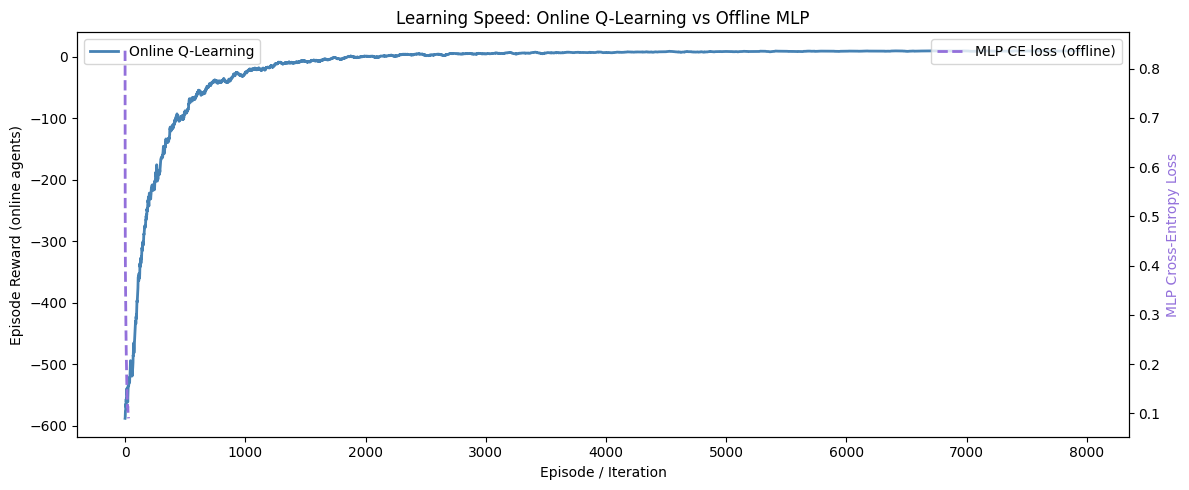

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))

# Online Q-Learning reward curve
ax.plot(smooth(hist_ql['rewards']), color='steelblue', lw=2, label='Online Q-Learning')

# Offline MLP loss on second y-axis
ax2 = ax.twinx()
ax2.plot(mlp_errors, color='mediumpurple', lw=2, ls='--', label='MLP CE loss (offline)')
ax2.set_ylabel('MLP Cross-Entropy Loss', color='mediumpurple')

ax.set_xlabel('Episode / Iteration')
ax.set_ylabel('Episode Reward (online agents)')
ax.set_title('Learning Speed: Online Q-Learning vs Offline MLP')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

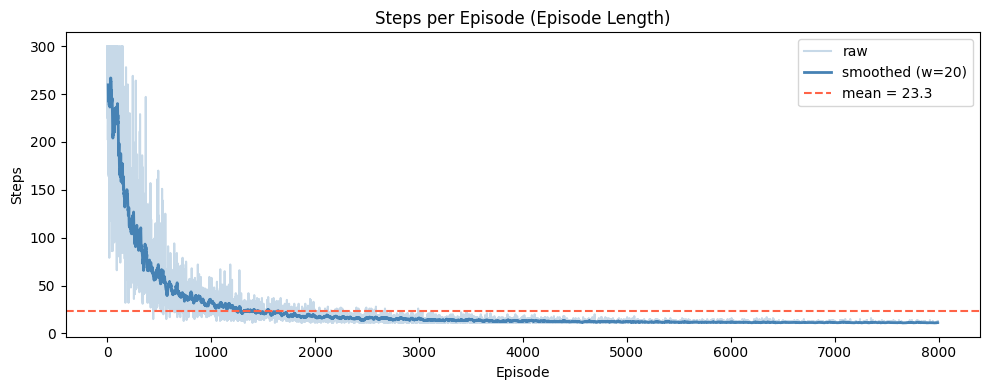

Mean episode length : 23.3
Min episode length  : 11
Max episode length  : 300


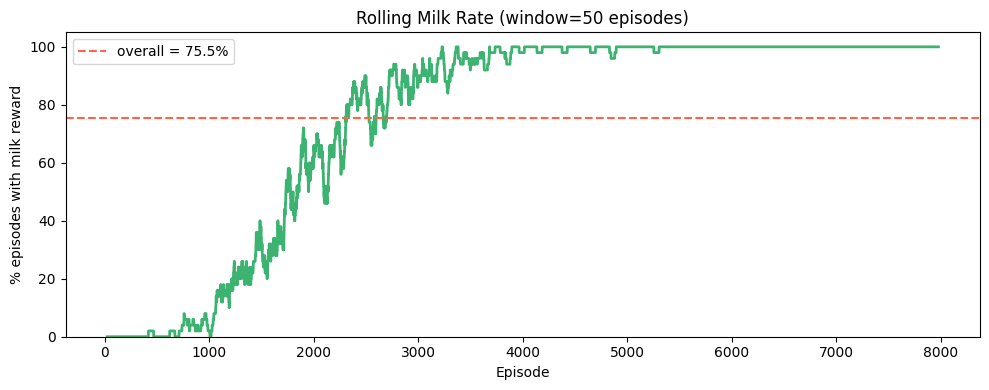

Overall milk rate: 75.5%


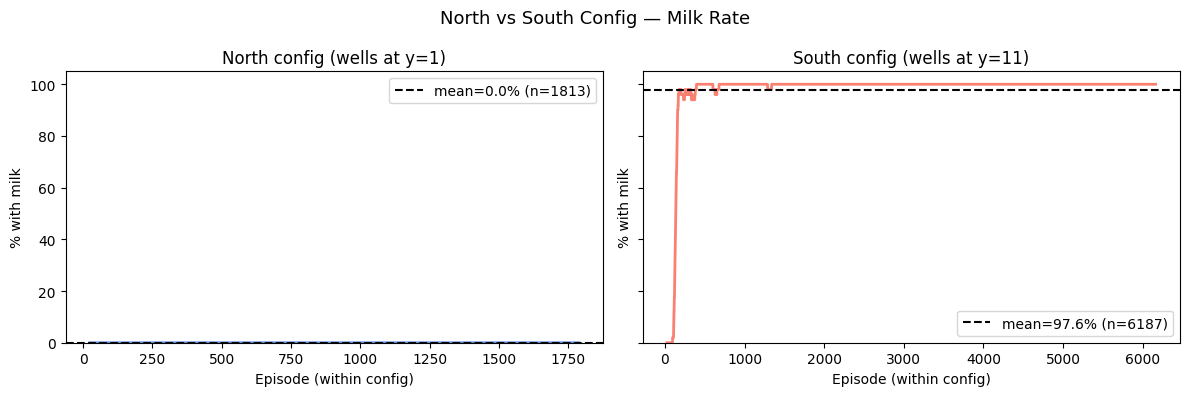

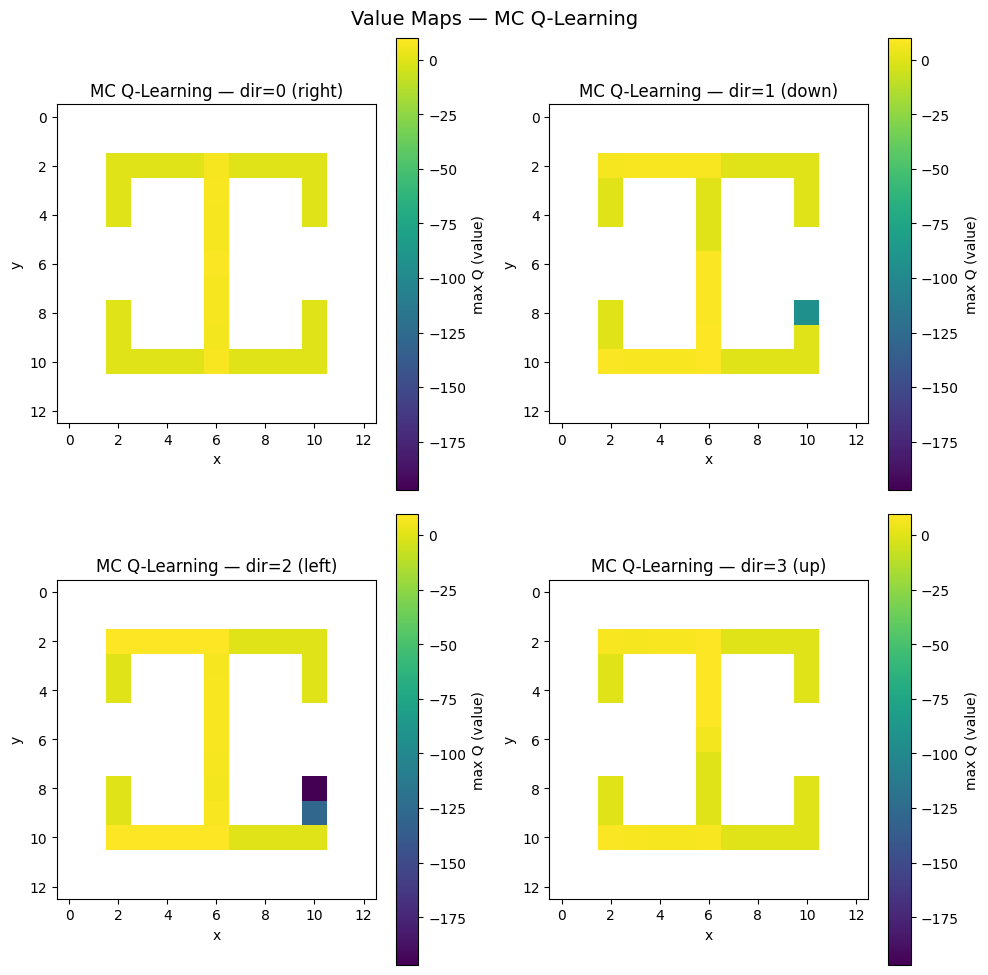

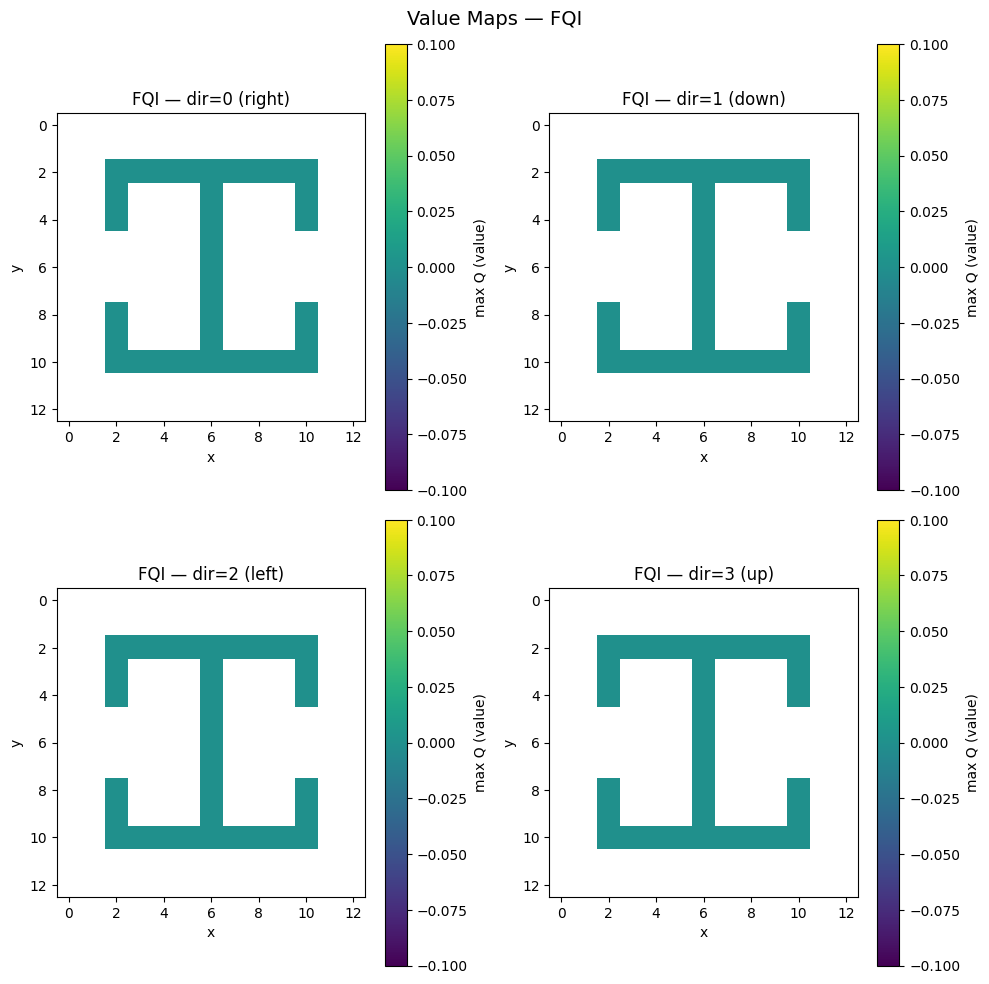

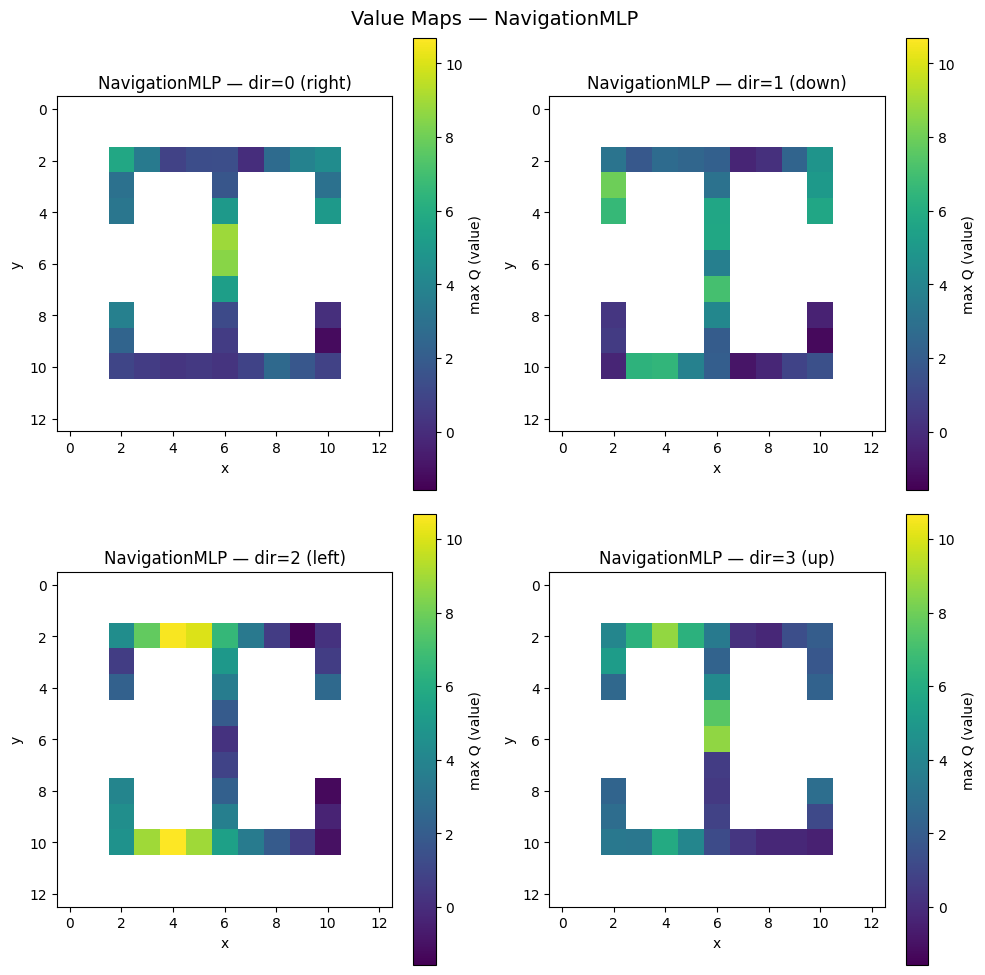

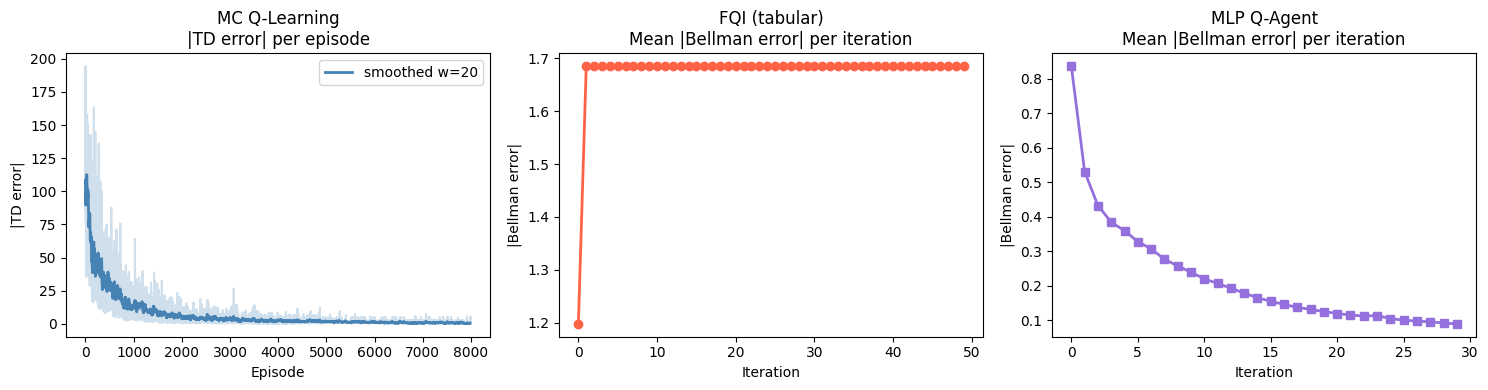

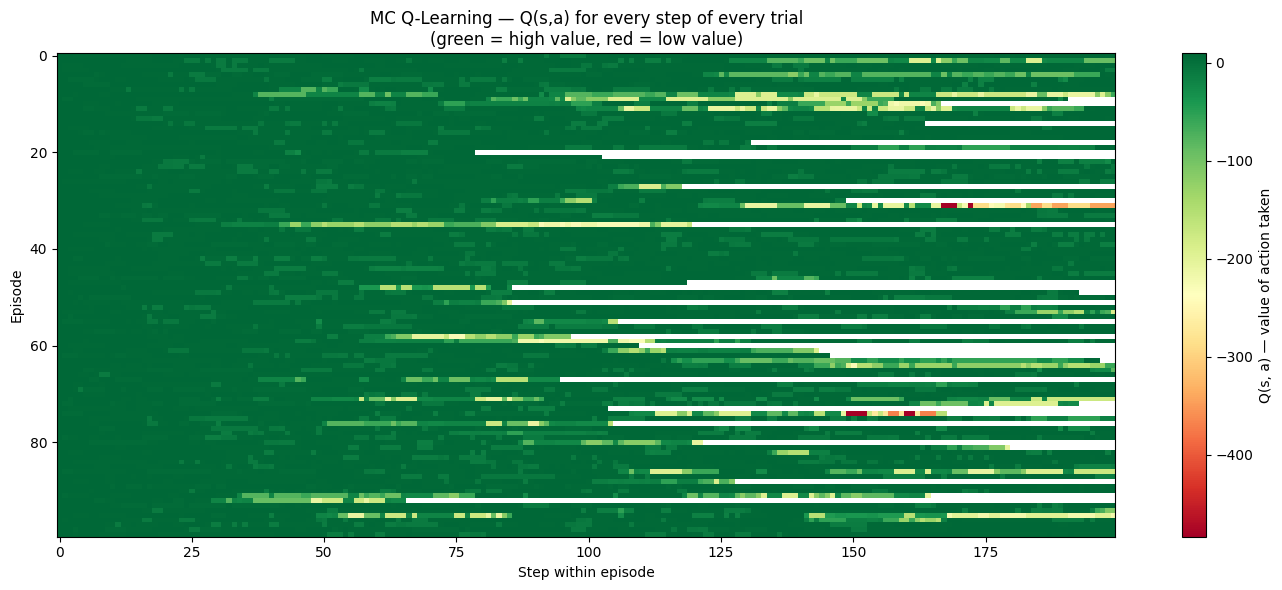

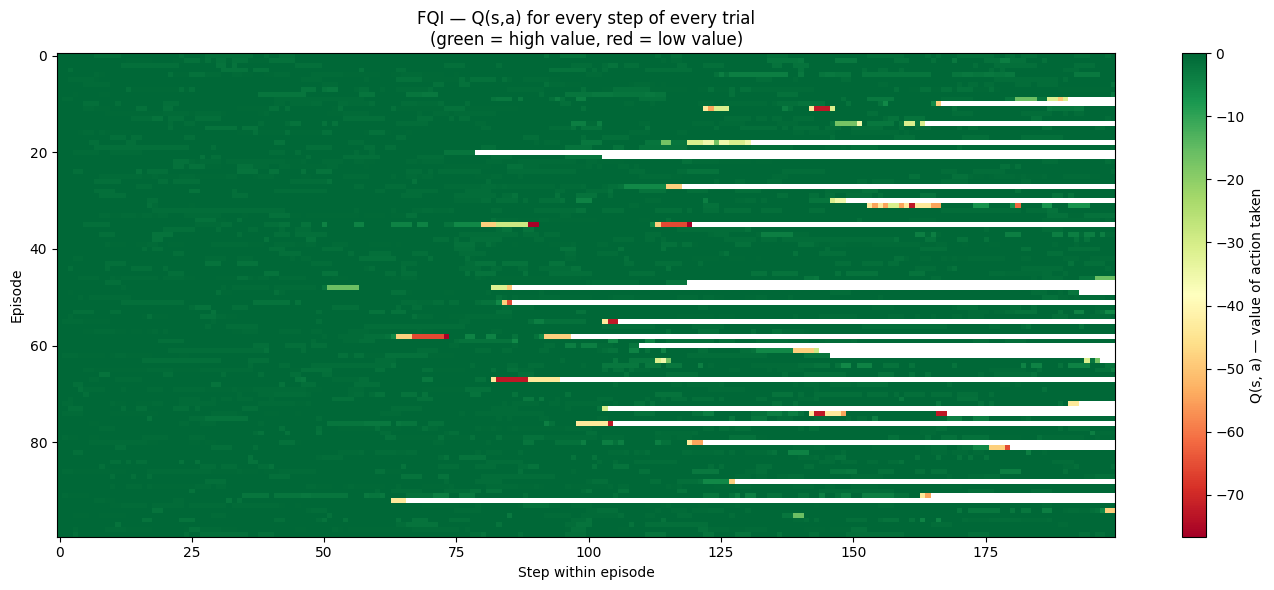

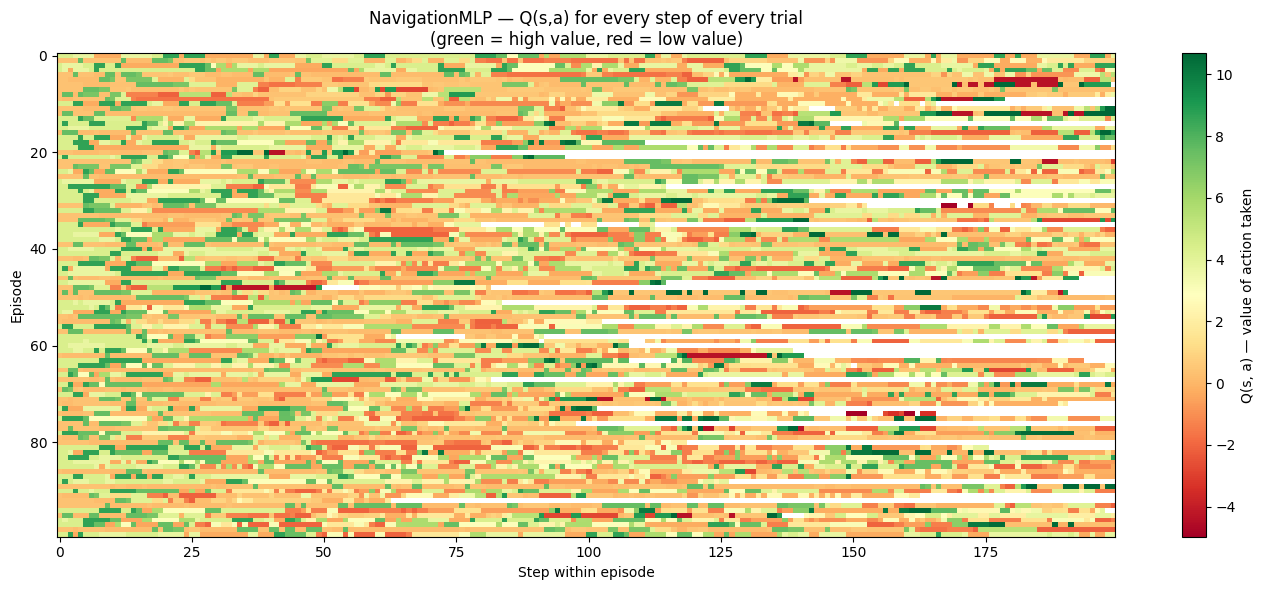

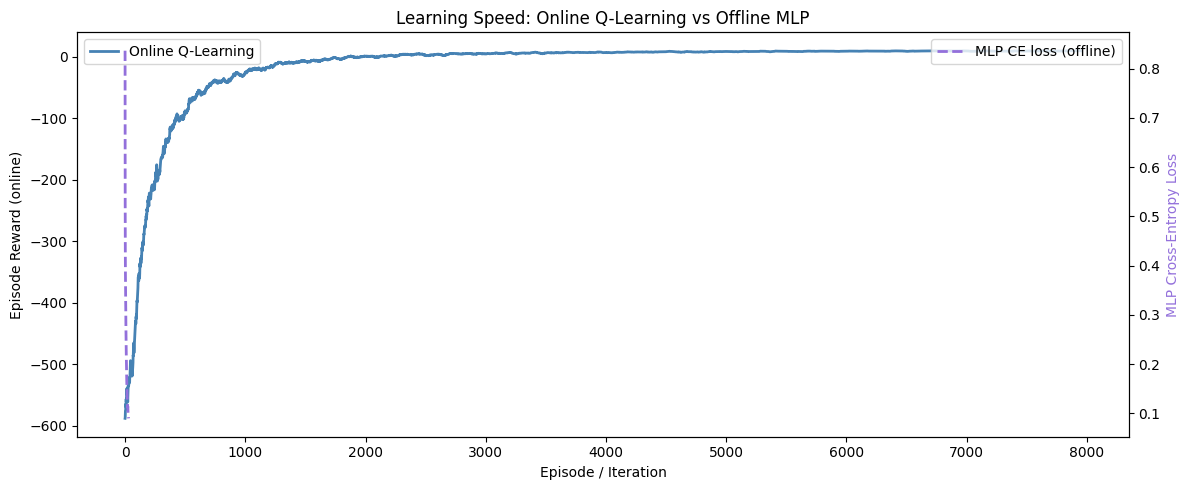

In [ ]:


# ── 1. Steps per episode over time ───────────────────────────────
plot_episode_lengths(dataset)

# ── 2. % episodes ending in milk ─────────────────────────────────
plot_milk_rate(dataset)

# ── 3. % north vs south config ending in milk ────────────────────
plot_north_south_milk(dataset)

# ── 4. Value maps all 4 directions for each agent ────────────────
plot_value_maps(mc_agent,  title="MC Q-Learning")
plot_value_maps(fqi_agent, title="FQI")
plot_value_maps(mlp_agent, title="NavigationMLP")

# ── 5. Training error curves ──────────────────────────────────────
plot_td_errors(
    mc_errors  = mc_errors,
    fqi_errors = fqi_errors,
    mlp_errors = mlp_errors,
)

# ── 6. TD value per state-action per step heatmap ────────────────
plot_state_action_td(mc_agent,  dataset, label="MC Q-Learning")
plot_state_action_td(fqi_agent, dataset, label="FQI")
plot_state_action_td(mlp_agent, dataset, label="NavigationMLP")

# ── 7. When does greedy policy stabilize (FQI only) ──────────────
#plot_exploration_decay(dataset, fqi_agent)

# ── 8. Learning speed: online vs offline MLP ─────────────────────
import matplotlib.pyplot as plt

def smooth(x, w=50):
    import numpy as np
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(hist_ql['rewards']), color='steelblue', lw=2,
        label='Online Q-Learning')
ax2 = ax.twinx()
ax2.plot(mlp_errors, color='mediumpurple', lw=2, ls='--',
         label='MLP CE loss (offline)')
ax2.set_ylabel('MLP Cross-Entropy Loss', color='mediumpurple')
ax.set_xlabel('Episode / Iteration')
ax.set_ylabel('Episode Reward (online)')
ax.set_title('Learning Speed: Online Q-Learning vs Offline MLP')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Number of trajectories: {len(hist_ql_full['trajectories'])}")
print(f"Number of rewards: {len(hist_ql_full['rewards'])}")
print(f"Last 500 milk rate: {np.mean(hist_ql['milk_chosen'][-500:]):.0%}")

Number of trajectories: 8000
Number of rewards: 8000
Last 500 milk rate: 100%


In [ ]:
# Manually walk to a well to confirm the env works
from milkmaze_env import CornerMazeEnv
env = CornerMazeEnv(render_mode=None)
obs, _ = env.reset(options={'start_config': 0})
# Config 0 path to milk: left, forward x4, left, forward x4, toggle
for action in [0, 2,2,2,2, 0, 2,2,2,2, 5]:
    obs, r, term, trunc, _ = env.step(action)
    if r != 0:
        print(f"Reward received: {r}")
        break

Reward received: 10


---
# Combined Online - Offline Training

Confirmed: 136 states, 7 actions
Q_ql max=10.000, Q_sa max=10.000

Q-LEARNING (from scratch)
  [Q-Learning] iter  1/30 | ε=0.970 | online milk= 18.8% | MLP milk=  0.0% | nav_data=514/8,714 transitions
  [Q-Learning] iter  2/30 | ε=0.941 | online milk= 28.1% | MLP milk=  0.0% | nav_data=1,513/16,414 transitions
  [Q-Learning] iter  3/30 | ε=0.913 | online milk= 46.9% | MLP milk=  0.0% | nav_data=2,660/22,756 transitions
  [Q-Learning] iter  4/30 | ε=0.885 | online milk= 59.4% | MLP milk=  0.0% | nav_data=3,745/26,717 transitions
  [Q-Learning] iter  5/30 | ε=0.859 | online milk= 53.1% | MLP milk=  0.0% | nav_data=4,694/30,247 transitions
  [Q-Learning] iter  6/30 | ε=0.833 | online milk= 81.2% | MLP milk=  0.0% | nav_data=5,777/32,870 transitions
  [Q-Learning] iter  7/30 | ε=0.808 | online milk= 75.0% | MLP milk= 65.6% | nav_data=6,679/35,357 transitions
  [Q-Learning] iter  8/30 | ε=0.784 | online milk= 90.6% | MLP milk=100.0% | nav_data=7,709/37,528 transitions
  [Q-Learning] iter  9

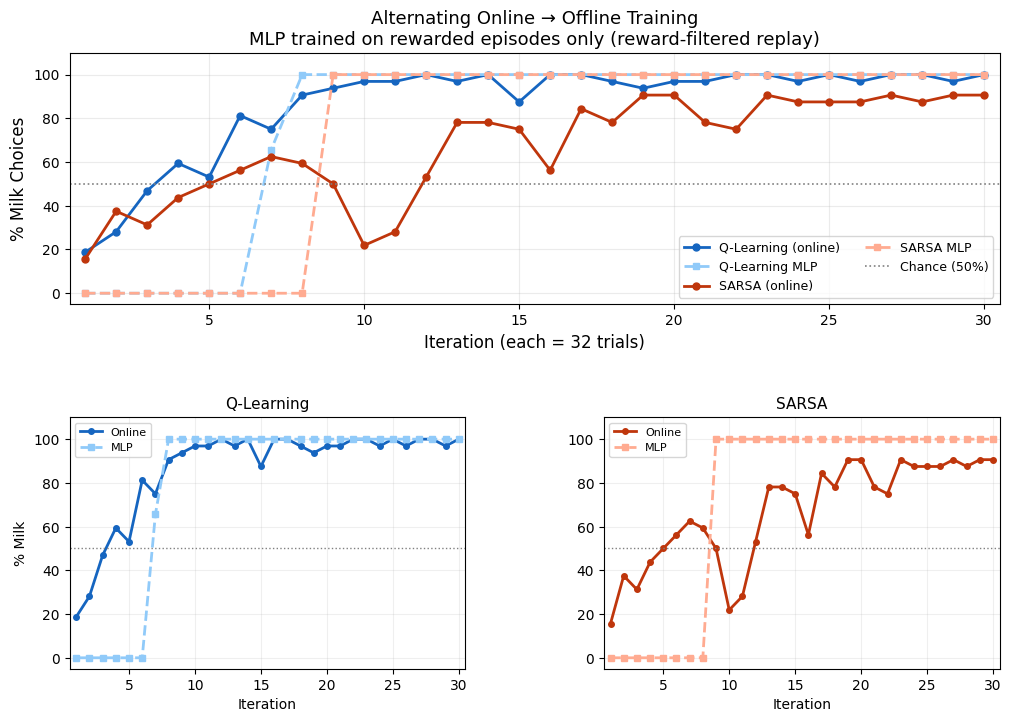

Saved: alternating_milk_rates.png

SUMMARY — Milk Rate (%) at key iterations
Agent            Online_1 Online_15 Online_30 |  MLP_1  MLP_15  MLP_30
---------------------------------------------------------------------------
Q-Learning           18.8      87.5     100.0 |    0.0   100.0   100.0
SARSA                15.6      75.0      90.6 |    0.0   100.0   100.0


In [ ]:
# ══════════════════════════════════════════════════════════════════
# ALTERNATING ONLINE → OFFLINE TRAINING
# Q-Learning and SARSA only (model-based removed)
# MLP trains only on rewarded episodes (reward-filtered replay)
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from offline_agent import NavigationMLP
from milkmaze_env import CornerMazeEnv

# ── Hyperparameters ───────────────────────────────────────────────
N_ITERATIONS    = 30
TRIALS_PER_ITER = 32
MLP_EPOCHS      = 30       # more epochs since dataset is smaller (rewarded only)
MLP_LR          = 1e-3
GAMMA           = 0.99
MAX_STEPS       = 300
ALPHA           = 0.1
EPS_START       = 1.0
EPS_END         = 0.05
EPS_DECAY       = 0.97

MILK_WELLS  = [(1, 1), (1, 11)]
WATER_WELLS = [(11, 1), (11, 11)]

# ── Capture notebook globals ──────────────────────────────────────
_STATE_TO_IDX = STATE_TO_IDX
_N_STATES     = N_STATES
_N_ACTIONS    = N_ACTIONS

print(f"Confirmed: {len(_STATE_TO_IDX)} states, {_N_ACTIONS} actions")
print(f"Q_ql max={Q_ql.max():.3f}, Q_sa max={Q_sa.max():.3f}")

# ── Minimal self-contained MLP for the alternating loop ──────────
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleNavMLP:
    """
    Minimal 3-action MLP: left / right / forward.
    Input : (config, x, y, dir) normalised — 4 floats, NO td_error.
    Trained via behavioural cloning on rewarded-episode nav actions.
    Toggle is injected at corners externally in _run_mlp_block.
    """
    def __init__(self, lr=1e-3):
        self.net = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 3),
        )
        self.opt     = optim.Adam(self.net.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()

    def _encode(self, state):
        c, x, y, d = state
        return torch.tensor([c/1., x/12., y/12., d/3.], dtype=torch.float32)

    def train_on(self, nav_data, n_epochs=30, batch_size=512):
        if not nav_data:
            return
        X = torch.stack([self._encode(t['s']) for t in nav_data])
        Y = torch.tensor([t['a'] for t in nav_data], dtype=torch.long)
        n = len(nav_data)
        self.net.train()
        for _ in range(n_epochs):
            idx = torch.randperm(n)
            for start in range(0, n, batch_size):
                bi = idx[start:start+batch_size]
                loss = self.loss_fn(self.net(X[bi]), Y[bi])
                self.opt.zero_grad(); loss.backward(); self.opt.step()

    def act(self, state):
        self.net.eval()
        with torch.no_grad():
            logits = self.net(self._encode(state).unsqueeze(0)).squeeze(0)
            return int(torch.argmax(logits).item())  # returns 0, 1, or 2


# ── Helpers ───────────────────────────────────────────────────────

def _get_state(env):
    return (int(env.current_config_index), int(env.agent_pos[0]),
            int(env.agent_pos[1]), int(env.agent_dir))

def _is_milk(env):
    return (int(env.agent_pos[0]), int(env.agent_pos[1])) in MILK_WELLS

def _eps_greedy(Q, state, epsilon, n_actions, state_to_idx):
    if state not in state_to_idx or np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state_to_idx[state]]))


# ── Online block ──────────────────────────────────────────────────

def _run_online_block(Q, epsilon, mode, state_to_idx, n_actions, n_states):
    env = CornerMazeEnv(render_mode=None)
    all_transitions, milk_flags = [], []

    def choose(s, eps):
        return _eps_greedy(Q, s, eps, n_actions, state_to_idx)

    for trial in range(TRIALS_PER_ITER):
        obs, _ = env.reset()
        state  = _get_state(env)
        done, steps = False, 0
        ep_transitions = []

        if mode == 'sarsa':
            action = choose(state, epsilon)

        while not done and steps < MAX_STEPS:
            if mode == 'sarsa':
                act = action
            else:
                act = choose(state, epsilon)

            obs, reward, terminated, truncated, _ = env.step(act)
            next_state = _get_state(env)
            done = terminated or truncated

            if state in state_to_idx and next_state in state_to_idx:
                q_sa   = Q[state_to_idx[state]][act]
                q_next = np.max(Q[state_to_idx[next_state]])
                td_err = float(reward + GAMMA * q_next * (1 - float(done)) - q_sa)
            else:
                td_err = 0.0

            ep_transitions.append({
                "s": state, "a": int(act), "r": float(reward),
                "s_next": next_state, "done": done, "td_error": td_err,
            })

            if state in state_to_idx:
                s_idx = state_to_idx[state]
                if mode == 'sarsa':
                    next_action = choose(next_state, epsilon)
                    target = reward if done else (
                        reward + GAMMA * Q[state_to_idx[next_state]][next_action]
                        if next_state in state_to_idx else reward)
                    Q[s_idx, act] += ALPHA * (target - Q[s_idx, act])
                    action = next_action
                else:  # qlearning
                    target = reward if done else (
                        reward + GAMMA * np.max(Q[state_to_idx[next_state]])
                        if next_state in state_to_idx else reward)
                    Q[s_idx, act] += ALPHA * (target - Q[s_idx, act])

            state = next_state
            steps += 1

        # Tag every transition in this episode with whether it was rewarded
        got_milk = _is_milk(env)
        for t in ep_transitions:
            t['got_milk'] = got_milk

        all_transitions.extend(ep_transitions)
        milk_flags.append(1 if got_milk else 0)

    env.close()
    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    return Q, all_transitions, milk_flags, epsilon


# ── MLP evaluation block ──────────────────────────────────────────

def _run_mlp_block(mlp, state_to_idx):
    """No Q_online needed — SimpleNavMLP takes no td_error."""
    env = CornerMazeEnv(render_mode=None)
    milk_flags = []
    CORNER_POSITIONS = {(10, 2), (10, 10), (2, 10), (2, 2)}

    for _ in range(TRIALS_PER_ITER):
        obs, _ = env.reset()
        state  = _get_state(env)
        done, steps = False, 0

        while not done and steps < MAX_STEPS:
            pos = (state[1], state[2])
            action = 5 if pos in CORNER_POSITIONS else mlp.act(state)
            obs, reward, terminated, truncated, _ = env.step(action)
            state = _get_state(env)
            done = terminated or truncated
            steps += 1

        milk_flags.append(1 if _is_milk(env) else 0)

    env.close()
    return milk_flags


# ── Filter dataset to rewarded episodes only ─────────────────────

def _rewarded_only(iter_datasets, window=10):
    """
    Returns transitions from the last `window` iterations,
    filtered to only episodes where the agent reached a milk well.

    This is the key fix: the MLP learns only from successful trajectories,
    analogous to hippocampal replay preferentially replaying rewarded
    experiences during sleep consolidation.
    """
    window_data = []
    for d in iter_datasets[-window:]:
        window_data.extend(d)
    # Keep only transitions from milk-rewarded episodes
    rewarded = [t for t in window_data if t.get('got_milk', False)]
    return rewarded


# ── Main loop ─────────────────────────────────────────────────────

def run_loop(mode, Q_init, state_to_idx, n_states, n_actions, label,
             mlp_window_iters=10):
    Q       = Q_init.copy()
    epsilon = EPS_START

    iter_datasets        = []
    online_milk_per_iter = []
    mlp_milk_per_iter    = []

    # MLP initialized ONCE and fine-tuned each iteration
    # Lower lr for fine-tuning so later iterations don't overwrite early learning
    mlp = SimpleNavMLP(lr=3e-4)

    for it in range(1, N_ITERATIONS + 1):

        # (A) Online phase
        Q, new_trans, online_milk, epsilon = _run_online_block(
            Q, epsilon, mode, state_to_idx, n_actions, n_states)
        iter_datasets.append(new_trans)
        online_rate = float(np.mean(online_milk))
        online_milk_per_iter.append(online_rate)

        # (B) Fine-tune MLP on rewarded nav transitions (warm-start)
        nav_data = [t for t in _rewarded_only(iter_datasets, window=mlp_window_iters)
                    if t['a'] in [0, 1, 2]]
        mlp_trained = len(nav_data) > 0
        if mlp_trained:
            mlp.train_on(nav_data, n_epochs=MLP_EPOCHS)

        # (C) Evaluate MLP
        if mlp_trained:
            mlp_milk = _run_mlp_block(mlp, state_to_idx)
            mlp_rate = float(np.mean(mlp_milk))
        else:
            mlp_rate = 0.0
        mlp_milk_per_iter.append(mlp_rate)

        total_in_window = sum(len(d) for d in iter_datasets[-mlp_window_iters:])
        print(f"  [{label}] iter {it:2d}/{N_ITERATIONS} | ε={epsilon:.3f} | "
              f"online milk={online_rate*100:5.1f}% | "
              f"MLP milk={mlp_rate*100:5.1f}% | "
              f"nav_data={len(nav_data):,}/{total_in_window:,} transitions")

    return {"online": online_milk_per_iter, "mlp": mlp_milk_per_iter}


# ── Run Q-Learning and SARSA only ─────────────────────────────────

Q_zero = np.zeros((_N_STATES, _N_ACTIONS))

print("\n" + "="*60)
print("Q-LEARNING (from scratch)")
print("="*60)
res_ql = run_loop('qlearning', Q_zero, _STATE_TO_IDX, _N_STATES, _N_ACTIONS,
                  "Q-Learning")

print("\n" + "="*60)
print("SARSA (from scratch)")
print("="*60)
res_sa = run_loop('sarsa', Q_zero, _STATE_TO_IDX, _N_STATES, _N_ACTIONS,
                  "SARSA")


# ── Plot ──────────────────────────────────────────────────────────

iters = np.arange(1, N_ITERATIONS + 1)
cfg = {
    "Q-Learning": (res_ql, "#1565C0", "#90CAF9"),
    "SARSA":      (res_sa, "#BF360C", "#FFAB91"),
}

fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(2, 1, hspace=0.45)

ax_main = fig.add_subplot(gs[0])
for label, (res, col_on, col_mlp) in cfg.items():
    ax_main.plot(iters, np.array(res["online"]) * 100,
                 color=col_on,  lw=2, marker="o", markersize=5,
                 label=f"{label} (online)")
    ax_main.plot(iters, np.array(res["mlp"]) * 100,
                 color=col_mlp, lw=2, marker="s", markersize=5,
                 linestyle="--", label=f"{label} MLP")
ax_main.axhline(50, color="gray", ls=":", lw=1.2, label="Chance (50%)")
ax_main.set_xlim(0.5, N_ITERATIONS + 0.5)
ax_main.set_ylim(-5, 110)
ax_main.set_xlabel("Iteration (each = 32 trials)", fontsize=12)
ax_main.set_ylabel("% Milk Choices", fontsize=12)
ax_main.set_title(
    "Alternating Online → Offline Training\n"
    "MLP trained on rewarded episodes only (reward-filtered replay)",
    fontsize=13)
ax_main.legend(ncol=2, fontsize=9, loc="lower right")
ax_main.grid(True, alpha=0.25)

gs_bot = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.35)
for col_idx, (label, (res, col_on, col_mlp)) in enumerate(cfg.items()):
    ax = fig.add_subplot(gs_bot[col_idx])
    ax.plot(iters, np.array(res["online"]) * 100, color=col_on,  lw=2,
            marker="o", markersize=4, label="Online")
    ax.plot(iters, np.array(res["mlp"]) * 100,    color=col_mlp, lw=2,
            marker="s", markersize=4, linestyle="--", label="MLP")
    ax.axhline(50, color="gray", ls=":", lw=1)
    ax.set_xlim(0.5, N_ITERATIONS + 0.5)
    ax.set_ylim(-5, 110)
    ax.set_xlabel("Iteration", fontsize=10)
    ax.set_ylabel("% Milk" if col_idx == 0 else "", fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.savefig("/content/drive/MyDrive/Psych 119g Final Project/alternating_milk_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: alternating_milk_rates.png")


# ── Summary table ─────────────────────────────────────────────────

print("\n" + "=" * 75)
print("SUMMARY — Milk Rate (%) at key iterations")
print("=" * 75)
print(f"{'Agent':<16} {'Online_1':>8} {'Online_15':>9} {'Online_30':>9} |"
      f" {'MLP_1':>6} {'MLP_15':>7} {'MLP_30':>7}")
print("-" * 75)
for label, (res, _, _) in cfg.items():
    o = np.array(res["online"]) * 100
    m = np.array(res["mlp"])    * 100
    print(f"{label:<16} {o[0]:>8.1f} {o[14]:>9.1f} {o[-1]:>9.1f} |"
          f" {m[0]:>6.1f} {m[14]:>7.1f} {m[-1]:>7.1f}")
print("=" * 75)